# Notebook 1 — Clustering de países por perfil de riesgo de sarampión

## Contexto

El **FIFA World Cup 2026** se celebrará en México, Estados Unidos y Canadá.  
Las ciudades sede mexicanas son **CDMX** (Estadio Azteca), **Guadalajara** (Jalisco) y **Monterrey** (Nuevo León).

Miles de aficionados de distintos países llegarán a México en junio–julio 2026.  
El sarampión, considerado eliminado en muchos países, ha resurgido globalmente desde 2018.  
Los datos EFES 2026 ya muestran **4,232 casos confirmados (DIAGNOSTICO=1) en Jalisco** hasta marzo 2026.

## Objetivo de este notebook

Usar **aprendizaje no supervisado (K-Means + análisis jerárquico)** para:

1. Agrupar los países del mundo según su perfil de riesgo de sarampión (incidencia histórica, cobertura vacunal, volumen de pasajeros a México).
2. Identificar qué grupos de países representan mayor riesgo de **importar** el virus durante el Mundial.
3. Generar una feature `riesgo_importado` por país que se usará en el modelo supervisado.

## Datasets utilizados

| Dataset | Variable clave |
|---|---|
| `WHO_Provisional_measles_and_rubella_data.csv` | Casos de sarampión por país/mes 2012–2026 |
| `WHO_vaccination-coverage.csv` | Cobertura MCV1 (primera dosis) por país/año |
| `Llegadas_aeropuerto_Extranjeros_Hoja3_.csv` | Flujo de pasajeros internacionales a México |

In [ ]:
import os

for path in [
    'content/data/raw',
    'content/data/processed',
    'content/reports',
    'content/reports/figures',
    'content/models'
]:
    os.makedirs(path, exist_ok=True)

print("Estructura de carpetas verificada ✅")

Estructura de carpetas verificada ✅


---
## 0. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

import os
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Rutas de datos — ajusta si tu estructura de carpetas es distinta
DATA_RAW = '../content/raw/'

# Crear carpeta si no existe
os.makedirs(DATA_RAW, exist_ok=True)

print(f'Carpeta verificada/creada correctamente: {DATA_RAW}')

print('Librerías importadas correctamente.')

Carpeta verificada/creada correctamente: ../content/raw/
Librerías importadas correctamente.


In [ ]:
import os
import shutil

# Define the source and destination directories
source_dir = '/content/'
dest_dir = '../content/raw/'

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# List all files in the source directory
files_in_source = os.listdir(source_dir)

print(f"Moving files to: {dest_dir}")

# Iterate through the files and move CSV/XLSX to the destination
for filename in files_in_source:
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        source_path = os.path.join(source_dir, filename)
        dest_path = os.path.join(dest_dir, filename)
        try:
            shutil.move(source_path, dest_path)
            print(f"Moved: {filename}")
        except Exception as e:
            print(f"Error moving {filename}: {e}")

print("File transfer complete.")

Moving files to: ../content/raw/
Moved: 2026_efes_abierto_090326.csv
Moved: Movimiento_operacional_de_vuelos.csv
Moved: 2024_efes_abierto_301024.xlsx
Moved: Movimiento_operacional_de_pasajeros_de_AICM.csv
Moved: Llegadas_internacionales_cdmx_mensual.csv
Moved: 2022_efes_abierto_261222.csv
Moved: WHO_Provisional_measles_and_rubella_data.csv
Moved: WHO_vaccination-coverage.csv
Moved: 2021_efes_abierto_271221.csv
Moved: 2025_efes_abierto_171225.csv
Moved: 2023_efes_abierto_271223.csv
Moved: Movimiento_operacional_de_pasajeros_por_terminal.csv
Moved: 2020_efes_abierto_281220.csv
Moved: Llegadas_aeropuerto_Extranjeros(Hoja3).csv
File transfer complete.


---
## 1. Carga y limpieza de datos

### 1.1 Casos de sarampión — WHO

In [ ]:
# Cargar el dataset de casos WHO
# Separador punto y coma, encoding utf-8-sig (tiene BOM)
measles_raw = pd.read_csv(
    DATA_RAW + 'WHO_Provisional_measles_and_rubella_data.csv',
    sep=';',
    encoding='utf-8-sig'
)

# Limpiar nombres de columnas (tienen saltos de línea)
measles_raw.columns = [
    c.strip().replace('\n', ' ').replace('  ', ' ')
    for c in measles_raw.columns
]

print('Columnas:', list(measles_raw.columns))
print(f'Shape: {measles_raw.shape}')
print(f'Años disponibles: {measles_raw["Year"].min()} – {measles_raw["Year"].max()}')
print(f'Países únicos: {measles_raw["Country"].nunique()}')
measles_raw.head(3)

Columnas: ['Region', 'Country', 'ISO3', 'Year', 'Month', 'Measles suspect', 'Measles clinical', 'Measles epi-linked', 'Measles lab-confirmed', 'Measles total', 'Rubella clinical', 'Rubella epi-linked', 'Rubella lab-confirmed', 'Rubella Total', 'Discarded', 'Unnamed: 15', 'Unnamed: 16']
Shape: (24088, 17)
Años disponibles: 2012 – 2026
Países únicos: 193


,Region,Country,ISO3,Year,Month,Measles suspect,Measles clinical,Measles epi-linked,Measles lab-confirmed,Measles total,Rubella clinical,Rubella epi-linked,Rubella lab-confirmed,Rubella Total,Discarded,Unnamed: 15,Unnamed: 16
0,AFR,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,AFR,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,AFR,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [ ]:
# Renombrar columnas clave para facilitar el trabajo
# Después del limpiado de nombres en la celda anterior,
# los \n ya fueron reemplazados por espacios simples.
measles = measles_raw.rename(columns={
    'Measles total':         'measles_total',
    'Measles lab-confirmed': 'measles_lab',
    'Measles suspect':       'measles_suspect',
    'Discarded':             'discarded'
})

measles['measles_total'] = pd.to_numeric(measles['measles_total'], errors='coerce')
measles['measles_lab']   = pd.to_numeric(measles['measles_lab'],   errors='coerce')

measles = measles.dropna(subset=['measles_total'])

print(f'Registros con datos de casos: {len(measles):,}')
print(f'Nulos en measles_total: {measles["measles_total"].isna().sum()}')


Registros con datos de casos: 23,939
Nulos en measles_total: 0


### 1.2 Cobertura de vacunación — WHO

In [ ]:
vax_raw = pd.read_csv(DATA_RAW + 'WHO_vaccination-coverage.csv')

# Renombrar para facilitar acceso
vax = vax_raw.rename(columns={
    'Entity': 'Country',
    'Code': 'ISO3',
    'Measles, first dose (MCV1)': 'mcv1'
})[['Country', 'ISO3', 'Year', 'mcv1']].copy()

vax['mcv1'] = pd.to_numeric(vax['mcv1'], errors='coerce')

print(f'Shape: {vax.shape}')
print(f'Años: {vax["Year"].min()} – {vax["Year"].max()}')
print(f'Países con MCV1: {vax["Country"].nunique()}')
vax.head(3)

Shape: (8825, 4)
Años: 1980 – 2023
Países con MCV1: 215


,Country,ISO3,Year,mcv1
0,Afghanistan,AFG,1980,11.0
1,Afghanistan,AFG,1981,NaN
2,Afghanistan,AFG,1982,8.0


### 1.3 Dataset de asistencia al Mundial — Kaggle

Usamos este dataset para saber qué países han participado históricamente y estimar su presencia en el 2026.

In [ ]:
# ── 1.3 Equipos confirmados para jugar en México — Mundial 2026 ──────────────

# Partidos confirmados en sedes mexicanas
partidos_mexico = [
    {'fecha': '2026-06-11', 'ciudad': 'CDMX',        'home': 'Mexico',       'away': 'South Africa'},
    {'fecha': '2026-06-11', 'ciudad': 'Guadalajara',  'home': 'South Korea',  'away': 'Rep. UEFA D'},
    {'fecha': '2026-06-14', 'ciudad': 'Monterrey',    'home': 'Tunisia',      'away': 'Rep. UEFA F'},
    {'fecha': '2026-06-17', 'ciudad': 'CDMX',        'home': 'Uzbekistan',   'away': 'Colombia'},
    {'fecha': '2026-06-18', 'ciudad': 'Guadalajara',  'home': 'Mexico',       'away': 'South Korea'},
    {'fecha': '2026-06-20', 'ciudad': 'Monterrey',    'home': 'Japan',        'away': 'Tunisia'},
    {'fecha': '2026-06-23', 'ciudad': 'Guadalajara',  'home': 'Colombia',     'away': 'Rep. Intercont. 2'},
    {'fecha': '2026-06-24', 'ciudad': 'CDMX',        'home': 'Rep. UEFA D',  'away': 'Mexico'},
    {'fecha': '2026-06-24', 'ciudad': 'Monterrey',    'home': 'South Africa', 'away': 'South Korea'},
    {'fecha': '2026-06-26', 'ciudad': 'Guadalajara',  'home': 'Spain',        'away': 'Uruguay'},
]

df_partidos_mexico = pd.DataFrame(partidos_mexico)
df_partidos_mexico['fecha'] = pd.to_datetime(df_partidos_mexico['fecha'])

equipos_confirmados = [
    'Mexico', 'South Africa', 'South Korea', 'Tunisia',
    'Uzbekistan', 'Colombia', 'Japan', 'Spain', 'Uruguay'
]

# Partidos por equipo y ciudad sede
equipos_por_ciudad = (
    pd.concat([
        df_partidos_mexico[['ciudad', 'home']].rename(columns={'home': 'Country'}),
        df_partidos_mexico[['ciudad', 'away']].rename(columns={'away': 'Country'})
    ])
    .query("Country not in ['Rep. UEFA D', 'Rep. UEFA F', 'Rep. Intercont. 2']")
    .groupby(['Country', 'ciudad'])
    .size()
    .reset_index(name='partidos_en_mexico')
)

# Ciudad sede principal por equipo (donde juega más partidos)
ciudad_principal = (
    equipos_por_ciudad
    .sort_values('partidos_en_mexico', ascending=False)
    .groupby('Country').first()
    .reset_index()[['Country', 'ciudad']]
    .rename(columns={'ciudad': 'ciudad_sede'})
)

print("Partidos por equipo y ciudad:")
print(equipos_por_ciudad.sort_values(['Country', 'ciudad']).to_string(index=False))

Partidos por equipo y ciudad:
     Country      ciudad  partidos_en_mexico
    Colombia        CDMX                   1
    Colombia Guadalajara                   1
       Japan   Monterrey                   1
      Mexico        CDMX                   2
      Mexico Guadalajara                   1
South Africa        CDMX                   1
South Africa   Monterrey                   1
 South Korea Guadalajara                   2
 South Korea   Monterrey                   1
       Spain Guadalajara                   1
     Tunisia   Monterrey                   2
     Uruguay Guadalajara                   1
  Uzbekistan        CDMX                   1


In [ ]:
# Asistencia promedio por equipo — Qatar 2022
# Solo para los 9 confirmados en México

import kagglehub
from kagglehub import KaggleDatasetAdapter

df_qatar = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "parasharmanas/qatar-2022-fifa-world-cup-attendance",
    "Attendance Sheet.csv"
)

home_teams = df_qatar[['Home', 'Attendance']].rename(columns={'Home': 'Country'})
away_teams = df_qatar[['Away', 'Attendance']].rename(columns={'Away': 'Country'})

asistencia_qatar = (
    pd.concat([home_teams, away_teams])
    .assign(Attendance=lambda x: pd.to_numeric(
        x['Attendance'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    ))
    .groupby('Country')
    .agg(asistencia_promedio=('Attendance', 'mean'))
    .reset_index()
    # Solo equipos que juegan en México
    .query("Country in @equipos_confirmados")
)

print("Asistencia promedio Qatar 2022 — equipos en México:")
print(asistencia_qatar.sort_values('asistencia_promedio', ascending=False).to_string(index=False))

Using Colab cache for faster access to the 'qatar-2022-fifa-world-cup-attendance' dataset.
Asistencia promedio Qatar 2022 — equipos en México:
Country  asistencia_promedio
Uruguay         88668.000000
 Mexico         71106.666667
  Spain         49606.500000
  Japan         42865.250000
Tunisia         42791.666667


In [ ]:
# Historial mundialista 1930-2018 — partidos jugados por país
# Solo para los 9 confirmados en México

import kagglehub

path = kagglehub.dataset_download("evangower/fifa-world-cup")
wc_matches = pd.read_csv(path + "/wcmatches.csv")

all_hist_teams = (
    pd.concat([
        wc_matches[['home_team']].rename(columns={'home_team': 'Country'}),
        wc_matches[['away_team']].rename(columns={'away_team': 'Country'})
    ])
    .value_counts()
    .reset_index()
)
all_hist_teams.columns = ['Country', 'partidos_historicos']

hist_wc_mexico = (
    all_hist_teams
    .query("Country in @equipos_confirmados")
)

print("Historial mundialista — equipos en México:")
print(hist_wc_mexico.sort_values('partidos_historicos', ascending=False).to_string(index=False))

Using Colab cache for faster access to the 'fifa-world-cup' dataset.
Historial mundialista — equipos en México:
     Country  partidos_historicos
       Spain                   63
      Mexico                   57
     Uruguay                   56
 South Korea                   34
    Colombia                   22
       Japan                   21
     Tunisia                   15
South Africa                    9


In [ ]:
# wc_participation final — une las tres fuentes
wc_participation = (
    pd.DataFrame({'Country': equipos_confirmados})
    .merge(ciudad_principal,                          on='Country', how='left')
    .merge(
        equipos_por_ciudad.groupby('Country')['partidos_en_mexico'].sum().reset_index(),
        on='Country', how='left'
    )
    .merge(asistencia_qatar,                          on='Country', how='left')
    .merge(all_hist_teams[['Country', 'partidos_historicos']], on='Country', how='left')
    .fillna({'asistencia_promedio': 0, 'partidos_historicos': 0})
    .assign(clasificado_2026=1)
)

wc_participation['partidos_historicos'] = wc_participation['partidos_historicos'].astype(int)
wc_participation['partidos_en_mexico']  = wc_participation['partidos_en_mexico'].astype(int)

print(f'Equipos en wc_participation: {len(wc_participation)}')
print(wc_participation.sort_values('partidos_historicos', ascending=False).to_string(index=False))

Equipos en wc_participation: 9
     Country ciudad_sede  partidos_en_mexico  asistencia_promedio  partidos_historicos  clasificado_2026
       Spain Guadalajara                   1         49606.500000                   63                 1
      Mexico        CDMX                   3         71106.666667                   57                 1
     Uruguay Guadalajara                   1         88668.000000                   56                 1
 South Korea Guadalajara                   3             0.000000                   34                 1
    Colombia        CDMX                   2             0.000000                   22                 1
       Japan   Monterrey                   1         42865.250000                   21                 1
     Tunisia   Monterrey                   2         42791.666667                   15                 1
South Africa   Monterrey                   2             0.000000                    9                 1
  Uzbekistan        CDMX

### 1.4 Flujo de pasajeros internacionales al AICM

In [ ]:
# ── 1.4 Flujo de pasajeros internacionales ──────────────────────────────────
# Mapeo de meses en español a número
MES_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

# 1) AICM mensual (2015–2026) — más completo, base principal
aicm = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_de_AICM.csv')
aicm['mes_num'] = aicm['mes'].str.lower().map(MES_MAP)
aicm['fecha']  = pd.to_datetime(aicm[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1))
aicm = aicm[['fecha','pasajeros_nacionales','pasajeros_internacionales']].sort_values('fecha').reset_index(drop=True)
print(f'AICM mensual: {aicm["fecha"].min().date()} → {aicm["fecha"].max().date()} ({len(aicm)} filas)')

# 2) Por terminal T1/T2 (2016–2026)
terminal = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_por_terminal.csv')
terminal['mes_num'] = terminal['mes'].str.lower().map(MES_MAP)
terminal['fecha']   = pd.to_datetime(terminal[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1))
terminal['intl_t1'] = terminal['pasajeros_llegadas_internacionales_t1']
terminal['intl_t2'] = terminal['pasajeros_llegadas_internacionales_t2']
terminal['intl_total_terminal'] = terminal['intl_t1'] + terminal['intl_t2']
terminal = terminal[['fecha','intl_t1','intl_t2','intl_total_terminal']].sort_values('fecha').reset_index(drop=True)
print(f'Terminal:     {terminal["fecha"].min().date()} → {terminal["fecha"].max().date()} ({len(terminal)} filas)')

# 3) Vuelos internacionales mensuales (2015–2026)
vuelos = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_vuelos.csv')
vuelos['mes_num'] = vuelos['mes'].str.lower().map(MES_MAP)
vuelos['fecha']   = pd.to_datetime(vuelos[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1))
vuelos = vuelos[['fecha','operaciones_vuelos_nacionales','operaciones_vuelos_internacionales']].sort_values('fecha').reset_index(drop=True)
print(f'Vuelos:       {vuelos["fecha"].min().date()} → {vuelos["fecha"].max().date()} ({len(vuelos)} filas)')

# 4) Llegadas internacionales CDMX mensual (2018–2024)
cdmx = pd.read_csv(DATA_RAW + 'Llegadas_internacionales_cdmx_mensual.csv')
cdmx['fecha'] = pd.to_datetime(cdmx['fecha'])
cdmx = cdmx[['fecha','ciudad_de_mexico']].rename(columns={'ciudad_de_mexico':'intl_cdmx'}).sort_values('fecha').reset_index(drop=True)
print(f'CDMX intl:    {cdmx["fecha"].min().date()} → {cdmx["fecha"].max().date()} ({len(cdmx)} filas)')

# 5) Extranjeros anual — proxy Monterrey (2012–2024)
# 5) Extranjeros anual — proxy Monterrey (2012–2024)
mty_raw = pd.read_csv('/content/raw/Llegadas_aeropuerto_Extranjeros(Hoja3).csv', sep=';', encoding='utf-8-sig')
mty_raw.columns = ['anio','pax_nacionales','pax_internacionales','pax_total']
for col in ['pax_nacionales','pax_internacionales','pax_total']:
    mty_raw[col] = pd.to_numeric(
        mty_raw[col].astype(str).str.replace('.','',regex=False).str.strip(),
        errors='coerce'
    )
print(f'MTY anual:    {mty_raw["anio"].min()} → {mty_raw["anio"].max()} ({len(mty_raw)} filas)')

AICM mensual: 2015-01-01 → 2026-01-01 (133 filas)
Terminal:     2016-01-01 → 2026-01-01 (121 filas)
Vuelos:       2015-01-01 → 2026-01-01 (133 filas)
CDMX intl:    2018-09-30 → 2024-06-30 (70 filas)
MTY anual:    2012 → 2024 (13 filas)


In [ ]:
# Distribuir el total anual de Monterrey a meses usando el patrón estacional del AICM
# (el AICM es el único dataset mensual que cubre todos los años de MTY)

# Calcular peso estacional promedio por mes (usando AICM como referencia)
aicm['mes_num'] = aicm['fecha'].dt.month
estacional = (
    aicm.groupby('mes_num')['pasajeros_internacionales'].mean()
)
estacional = (estacional / estacional.sum()).rename('peso_mes')  # suma = 1.0

# Expandir MTY anual → mensual
mty_mensual_rows = []
for _, row in mty_raw.iterrows():
    for mes_num, peso in estacional.items():
        mty_mensual_rows.append({
            'fecha': pd.Timestamp(year=int(row['anio']), month=mes_num, day=1),
            'pax_intl_mty': row['pax_internacionales'] * peso
        })

mty_mensual = (
    pd.DataFrame(mty_mensual_rows)
    .sort_values('fecha')
    .reset_index(drop=True)
)
mty_mensual['pax_intl_mty'] = mty_mensual['pax_intl_mty'].round().astype(int)

print(f'MTY mensual proyectado: {mty_mensual["fecha"].min().date()} → {mty_mensual["fecha"].max().date()}')
print(mty_mensual.head(6).to_string(index=False))

MTY mensual proyectado: 2012-01-01 → 2024-12-01
     fecha  pax_intl_mty
2012-01-01         82529
2012-02-01         66739
2012-03-01         75711
2012-04-01         71043
2012-05-01         72816
2012-06-01         75934


In [ ]:
import os

# Crear carpeta si no existe
output_dir = 'content/reports/figures'
os.makedirs(output_dir, exist_ok=True)

# Guardar figura
plt.savefig(f'{output_dir}/pasajeros_tendencia_mundial.png',
            dpi=150,
            bbox_inches='tight')

<Figure size 768x576 with 0 Axes>

In [ ]:
import os

OUTPUT_FIGURES = 'content/reports/figures'

# Crear carpeta automáticamente si no existe
os.makedirs(OUTPUT_FIGURES, exist_ok=True)

# Guardar figura
filename = 'pasajeros_tendencia_mundial.png'
filepath = os.path.join(OUTPUT_FIGURES, filename)

plt.savefig(filepath, dpi=150, bbox_inches='tight')

print(f'Figura guardada correctamente en: {filepath}')

Figura guardada correctamente en: content/reports/figures/pasajeros_tendencia_mundial.png


<Figure size 768x576 with 0 Axes>

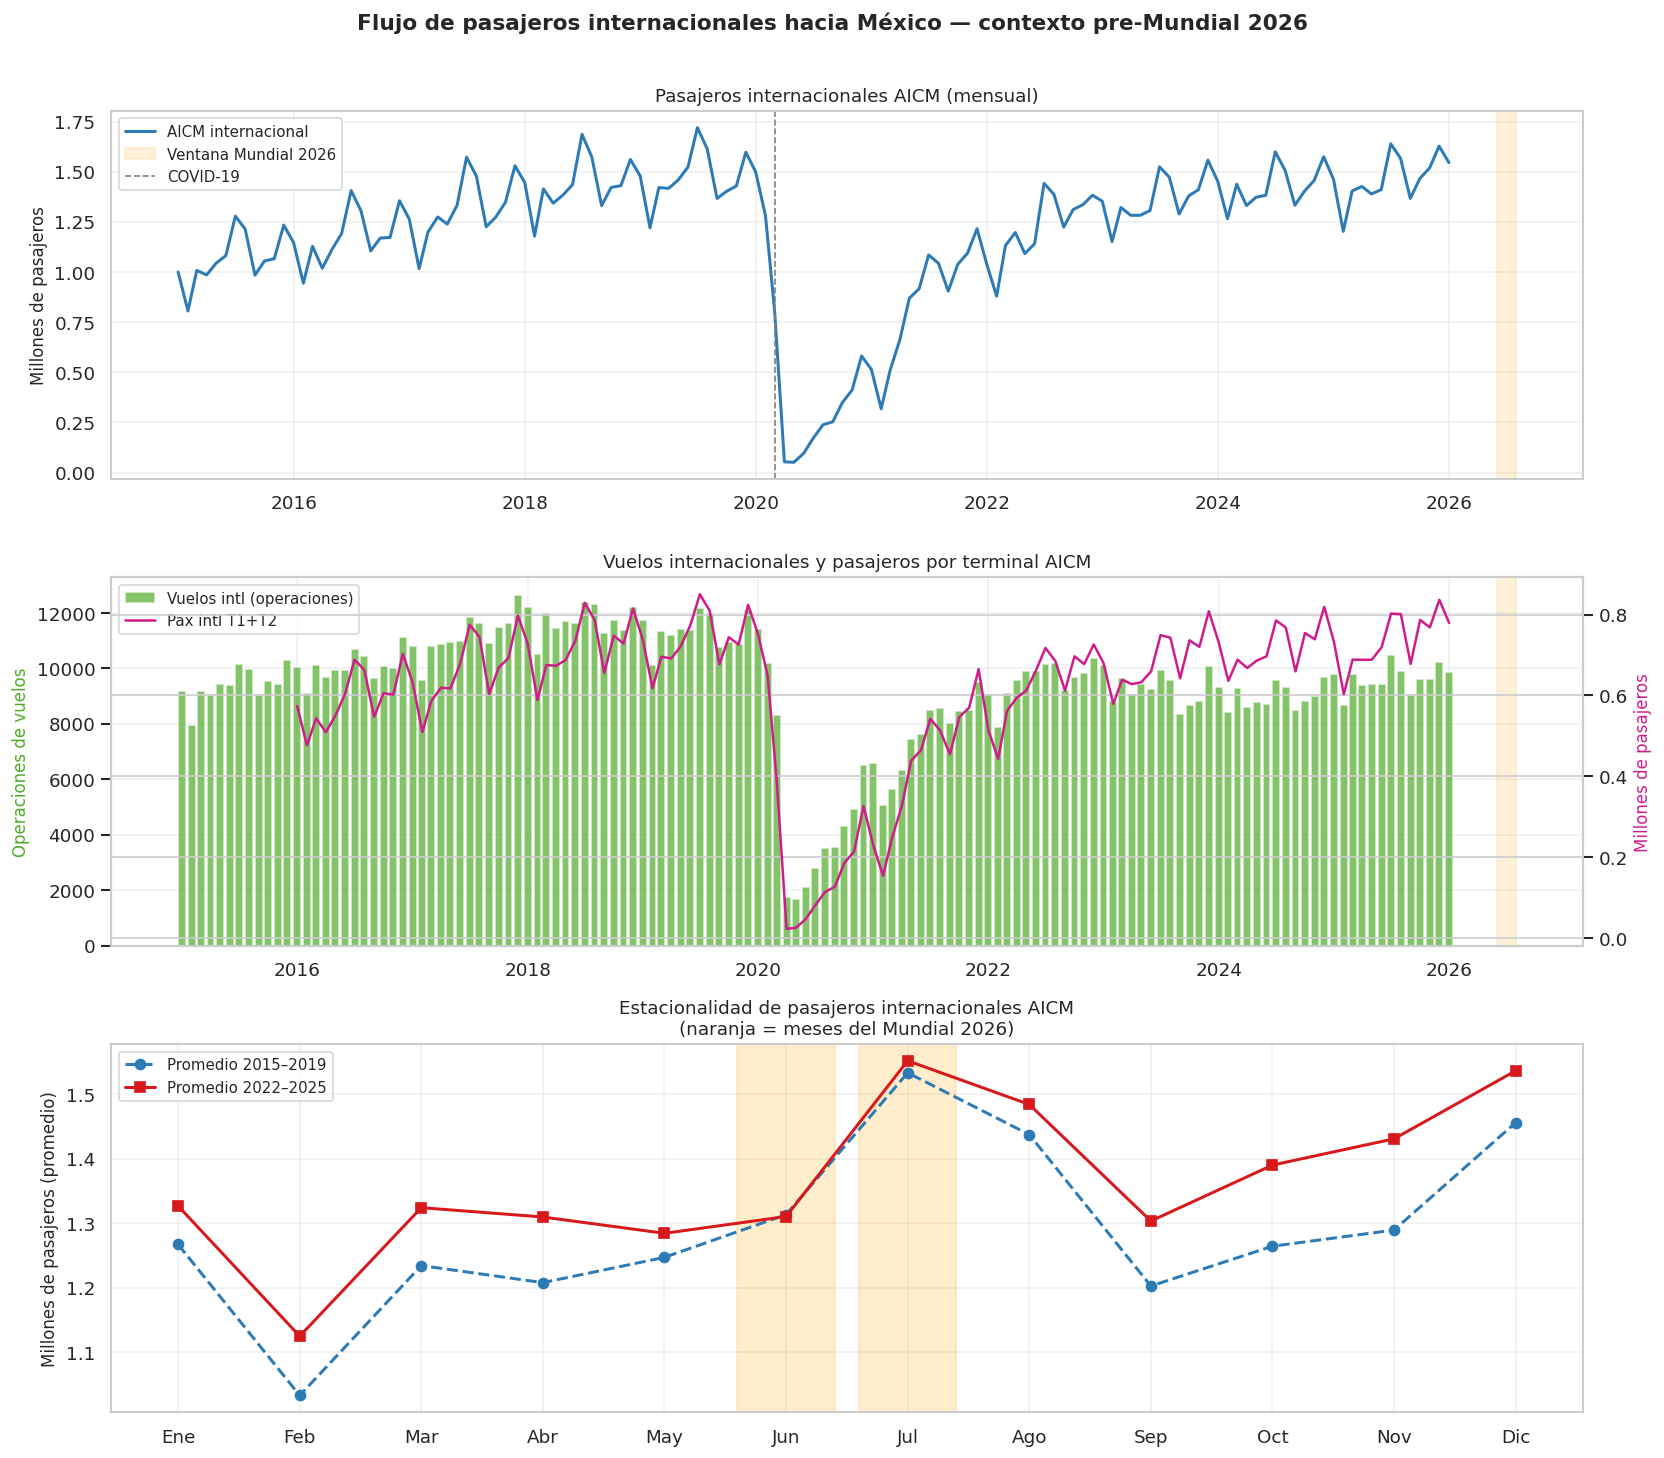


Resumen estadístico — pasajeros internacionales AICM:
anio
2015    12.76M
2016    14.06M
2017    15.75M
2018    17.20M
2019    17.65M
2020     5.79M
2021    10.17M
2022    14.56M
2023    16.33M
2024    17.12M
2025    17.48M
2026     1.55M


In [ ]:
# Fechas de partidos en México — Mundial 2026
partidos_data = [
    {'fecha': '2026-06-11', 'ciudad': 'CDMX',        'partido': 'MEX vs RSA'},
    {'fecha': '2026-06-11', 'ciudad': 'Guadalajara',  'partido': 'KOR vs EUR'},
    {'fecha': '2026-06-14', 'ciudad': 'Monterrey',    'partido': 'UKR vs TUN'},
    {'fecha': '2026-06-17', 'ciudad': 'CDMX',        'partido': 'UZB vs COL'},
    {'fecha': '2026-06-18', 'ciudad': 'Guadalajara',  'partido': 'MEX vs KOR'},
    {'fecha': '2026-06-20', 'ciudad': 'Monterrey',    'partido': 'TUN vs JPN'},
    {'fecha': '2026-06-24', 'ciudad': 'CDMX',        'partido': 'EUR vs MEX'},
    {'fecha': '2026-06-24', 'ciudad': 'Monterrey',    'partido': 'RSA vs KOR'},
    {'fecha': '2026-06-30', 'ciudad': 'CDMX',        'partido': '16vos Final'},
    {'fecha': '2026-07-05', 'ciudad': 'CDMX',        'partido': '8vos Final'},
]
df_mundial = pd.DataFrame(partidos_data)
df_mundial['fecha'] = pd.to_datetime(df_mundial['fecha'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# ── Gráfica 1: Pasajeros internacionales AICM mensual ───────────────────────
ax = axes[0]
ax.plot(aicm['fecha'], aicm['pasajeros_internacionales'] / 1e6,
        color='#2c7bb6', linewidth=1.8, label='AICM internacional')
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
           alpha=0.15, color='orange', label='Ventana Mundial 2026')
ax.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--',
           linewidth=1, label='COVID-19')
ax.set_ylabel('Millones de pasajeros', fontsize=10)
ax.set_title('Pasajeros internacionales AICM (mensual)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Gráfica 2: Vuelos internacionales + pasajeros por terminal ───────────────
ax = axes[1]
ax.bar(vuelos['fecha'], vuelos['operaciones_vuelos_internacionales'],
       width=25, color='#4dac26', alpha=0.7, label='Vuelos intl (operaciones)')
ax2 = ax.twinx()
ax2.plot(terminal['fecha'], terminal['intl_total_terminal'] / 1e6,
         color='#d01c8b', linewidth=1.5, label='Pax intl T1+T2')
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
           alpha=0.15, color='orange')
ax.set_ylabel('Operaciones de vuelos', fontsize=10, color='#4dac26')
ax2.set_ylabel('Millones de pasajeros', fontsize=10, color='#d01c8b')
ax.set_title('Vuelos internacionales y pasajeros por terminal AICM', fontsize=11)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(True, alpha=0.3)

# ── Gráfica 3: Estacionalidad mensual promedio (patrón pre/post COVID) ───────
ax = axes[2]
aicm['anio'] = aicm['fecha'].dt.year
aicm['mes_num'] = aicm['fecha'].dt.month

pre_covid  = aicm[aicm['anio'].between(2015, 2019)].groupby('mes_num')['pasajeros_internacionales'].mean()
post_covid = aicm[aicm['anio'].between(2022, 2025)].groupby('mes_num')['pasajeros_internacionales'].mean()

meses_label = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
x = np.arange(1, 13)
ax.plot(x, pre_covid  / 1e6, 'o--', color='#2c7bb6', label='Promedio 2015–2019', linewidth=1.8)
ax.plot(x, post_covid / 1e6, 's-',  color='#d7191c', label='Promedio 2022–2025', linewidth=1.8)

# Marcar junio y julio (meses del Mundial)
for m in [6, 7]:
    ax.axvspan(m - 0.4, m + 0.4, alpha=0.2, color='orange')

ax.set_xticks(x)
ax.set_xticklabels(meses_label)
ax.set_ylabel('Millones de pasajeros (promedio)', fontsize=10)
ax.set_title('Estacionalidad de pasajeros internacionales AICM\n(naranja = meses del Mundial 2026)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Flujo de pasajeros internacionales hacia México — contexto pre-Mundial 2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('content/reports/figures/pasajeros_tendencia_mundial.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen estadístico — pasajeros internacionales AICM:')
print(aicm.groupby('anio')['pasajeros_internacionales'].sum().apply(lambda x: f'{x/1e6:.2f}M').to_string())

---
## 2. Construcción del dataset para clustering

| Feature | Fuente | Interpretación |
|---|---|---|
| `total_cases` | WHO measles | Carga total de sarampión 2018-2024 |
| `avg_monthly_cases` | WHO measles | Promedio mensual de casos |
| `months_with_cases` | WHO measles | Persistencia del brote |
| `mcv1_mean` | WHO vaccination | Cobertura vacunal promedio |
| `mcv1_tendencia` | WHO vaccination | ¿Sube o baja la vacunación? |
| `asistencia_promedio` | Qatar 2022 | Proxy de tamaño de hinchada |
| `partidos_en_mexico` | FIFA 2026 | Partidos que juega en México |

In [ ]:
# Partidos confirmados en sedes mexicanas
partidos_mexico = [
    {'fecha': '2026-06-11', 'ciudad': 'CDMX',        'home': 'Mexico',       'away': 'South Africa'},
    {'fecha': '2026-06-11', 'ciudad': 'Guadalajara',  'home': 'South Korea',  'away': 'Rep. UEFA D'},
    {'fecha': '2026-06-14', 'ciudad': 'Monterrey',    'home': 'Tunisia',      'away': 'Rep. UEFA F'},
    {'fecha': '2026-06-17', 'ciudad': 'CDMX',        'home': 'Uzbekistan',   'away': 'Colombia'},
    {'fecha': '2026-06-18', 'ciudad': 'Guadalajara',  'home': 'Mexico',       'away': 'South Korea'},
    {'fecha': '2026-06-20', 'ciudad': 'Monterrey',    'home': 'Japan',        'away': 'Tunisia'},
    {'fecha': '2026-06-23', 'ciudad': 'Guadalajara',  'home': 'Colombia',     'away': 'Rep. Intercont. 2'},
    {'fecha': '2026-06-24', 'ciudad': 'CDMX',        'home': 'Rep. UEFA D',  'away': 'Mexico'},
    {'fecha': '2026-06-24', 'ciudad': 'Monterrey',    'home': 'South Africa', 'away': 'South Korea'},
    {'fecha': '2026-06-26', 'ciudad': 'Guadalajara',  'home': 'Spain',        'away': 'Uruguay'},
]

df_partidos_mexico = pd.DataFrame(partidos_mexico)
df_partidos_mexico['fecha'] = pd.to_datetime(df_partidos_mexico['fecha'])

REPECHAJES = ['Rep. UEFA D', 'Rep. UEFA F', 'Rep. Intercont. 2']

equipos_confirmados = [
    'Mexico', 'South Africa', 'South Korea', 'Tunisia',
    'Uzbekistan', 'Colombia', 'Japan', 'Spain', 'Uruguay'
]

# Partidos por equipo y ciudad
equipos_por_ciudad = (
    pd.concat([
        df_partidos_mexico[['ciudad', 'home']].rename(columns={'home': 'Country'}),
        df_partidos_mexico[['ciudad', 'away']].rename(columns={'away': 'Country'})
    ])
    .query("Country not in @REPECHAJES")
    .groupby(['Country', 'ciudad'])
    .size()
    .reset_index(name='partidos_en_mexico')
)

# Ciudad sede principal (donde más partidos juega)
ciudad_principal = (
    equipos_por_ciudad
    .sort_values('partidos_en_mexico', ascending=False)
    .groupby('Country').first()
    .reset_index()[['Country', 'ciudad']]
    .rename(columns={'ciudad': 'ciudad_sede'})
)

# Total de partidos en México por equipo
partidos_totales = (
    equipos_por_ciudad
    .groupby('Country')['partidos_en_mexico']
    .sum()
    .reset_index()
)

print("Partidos por equipo y ciudad:")
print(equipos_por_ciudad.sort_values(['Country', 'ciudad']).to_string(index=False))

Partidos por equipo y ciudad:
     Country      ciudad  partidos_en_mexico
    Colombia        CDMX                   1
    Colombia Guadalajara                   1
       Japan   Monterrey                   1
      Mexico        CDMX                   2
      Mexico Guadalajara                   1
South Africa        CDMX                   1
South Africa   Monterrey                   1
 South Korea Guadalajara                   2
 South Korea   Monterrey                   1
       Spain Guadalajara                   1
     Tunisia   Monterrey                   2
     Uruguay Guadalajara                   1
  Uzbekistan        CDMX                   1


In [ ]:
# Incidencia de sarampión 2018-2024
# Calculamos para todos los países y luego filtramos los 9 de México
measles_recent = measles[measles['Year'].between(2018, 2024)].copy()

measles_by_country = (
    measles_recent
    .groupby('Country')
    .agg(
        total_cases=('measles_total', 'sum'),
        avg_monthly_cases=('measles_total', 'mean'),
        months_with_cases=('measles_total', lambda x: (x > 0).sum()),
        peak_month=('measles_total', 'max')
    )
    .reset_index()
)

print("Casos de sarampión 2018-2024 — equipos en México:")
print(
    measles_by_country[measles_by_country['Country'].isin(equipos_confirmados)]
    .sort_values('total_cases', ascending=False)
    .to_string(index=False)
)

Casos de sarampión 2018-2024 — equipos en México:
     Country  total_cases  avg_monthly_cases  months_with_cases  peak_month
  Uzbekistan       8480.0         136.774194                 48      1618.0
     Tunisia       4756.0          58.716049                 56      1211.0
South Africa       2475.0          31.730769                 75       285.0
       Japan       1143.0          13.607143                 54       147.0
       Spain        868.0          11.421053                 51        99.0
    Colombia        447.0           6.208333                 23        43.0
      Mexico        223.0           3.097222                 12       139.0
     Uruguay         11.0           0.289474                  4         5.0


In [ ]:
# Cobertura MCV1 2018-2023 y tendencia lineal
from scipy import stats

vax_recent = vax[vax['Year'].between(2018, 2023)].copy()

vax_by_country = (
    vax_recent
    .groupby('Country')
    .agg(
        mcv1_mean=('mcv1', 'mean'),
        mcv1_min=('mcv1', 'min'),
        mcv1_std=('mcv1', 'std')
    )
    .reset_index()
)

def calc_slope(group):
    g = group.dropna(subset=['mcv1'])
    if len(g) < 3:
        return np.nan
    slope, _, _, _, _ = stats.linregress(g['Year'], g['mcv1'])
    return slope

vax_slope = (
    vax_recent
    .groupby('Country')
    .apply(calc_slope)
    .reset_index(name='mcv1_tendencia')
)

vax_by_country = vax_by_country.merge(vax_slope, on='Country', how='left')

print("Cobertura MCV1 — equipos en México:")
print(
    vax_by_country[vax_by_country['Country'].isin(equipos_confirmados)]
    .sort_values('mcv1_mean')
    [['Country', 'mcv1_mean', 'mcv1_min', 'mcv1_tendencia']]
    .to_string(index=False)
)

Cobertura MCV1 — equipos en México:
     Country  mcv1_mean  mcv1_min  mcv1_tendencia
South Africa  83.500000      80.0        0.200000
      Mexico  87.166667      73.0       -1.685714
    Colombia  91.166667      86.0       -1.000000
     Uruguay  95.500000      93.0       -0.200000
       Japan  96.333333      94.0       -0.342857
     Tunisia  96.333333      95.0       -0.342857
       Spain  96.500000      95.0       -0.485714
 South Korea  97.666667      97.0       -0.228571
  Uzbekistan  98.333333      96.0        0.514286


In [ ]:
# Join limpio — una sola pasada, sin merges acumulados
# Diccionario de nombres FIFA → nombres WHO (ajustar si hay NaN en el output)
nombre_who = {
    'Mexico':       'Mexico',
    'South Africa': 'South Africa',
    'South Korea':  'Republic of Korea',
    'Tunisia':      'Tunisia',
    'Uzbekistan':   'Uzbekistan',
    'Colombia':     'Colombia',
    'Japan':        'Japan',
    'Spain':        'Spain',
    'Uruguay':      'Uruguay',
}

# Tabla base: 9 equipos con nombre FIFA y nombre WHO
base = pd.DataFrame({
    'Country':     list(nombre_who.keys()),
    'Country_who': list(nombre_who.values())
})

# --- CORRECCIÓN: Etiquetar a los 9 equipos como clasificados ---
base['clasificado_2026'] = 1
# ---------------------------------------------------------------

cluster_df = (
    base
    .merge(ciudad_principal,   on='Country', how='left')
    .merge(partidos_totales,   on='Country', how='left')
    .merge(
        asistencia_qatar.rename(columns={'Country': 'Country_who'}),
        on='Country_who', how='left'
    )
    .merge(
        all_hist_teams.rename(columns={'Country': 'Country_who'}),
        on='Country_who', how='left'
    )
    .merge(
        measles_by_country.rename(columns={'Country': 'Country_who'})
        [['Country_who', 'total_cases', 'avg_monthly_cases', 'months_with_cases', 'peak_month']],
        on='Country_who', how='left'
    )
    .merge(
        vax_by_country.rename(columns={'Country': 'Country_who'})
        [['Country_who', 'mcv1_mean', 'mcv1_min', 'mcv1_std', 'mcv1_tendencia']],
        on='Country_who', how='left'
    )
)

# Imputar nulos con mediana
for col in ['total_cases', 'avg_monthly_cases', 'months_with_cases',
            'peak_month', 'mcv1_mean', 'mcv1_min', 'mcv1_std',
            'mcv1_tendencia', 'asistencia_promedio', 'partidos_historicos']:
    if col in cluster_df.columns:
        cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

cluster_df['partidos_historicos'] = cluster_df['partidos_historicos'].astype(int)
cluster_df['partidos_en_mexico']  = cluster_df['partidos_en_mexico'].astype(int)

print(f'Países en cluster_df: {len(cluster_df)}')
print(cluster_df[['Country', 'ciudad_sede', 'partidos_en_mexico',
                   'total_cases', 'mcv1_mean', 'asistencia_promedio', 'clasificado_2026']].to_string(index=False))

Países en cluster_df: 9
     Country ciudad_sede  partidos_en_mexico  total_cases  mcv1_mean  asistencia_promedio  clasificado_2026
      Mexico        CDMX                   3        223.0  87.166667         71106.666667                 1
South Africa   Monterrey                   2       2475.0  83.500000         49606.500000                 1
 South Korea Guadalajara                   3        273.0  95.916667         49606.500000                 1
     Tunisia   Monterrey                   2       4756.0  96.333333         42791.666667                 1
  Uzbekistan        CDMX                   1       8480.0  98.333333         49606.500000                 1
    Colombia        CDMX                   2        447.0  91.166667         49606.500000                 1
       Japan   Monterrey                   1       1143.0  96.333333         42865.250000                 1
       Spain Guadalajara                   1        868.0  96.500000         49606.500000                 1
    

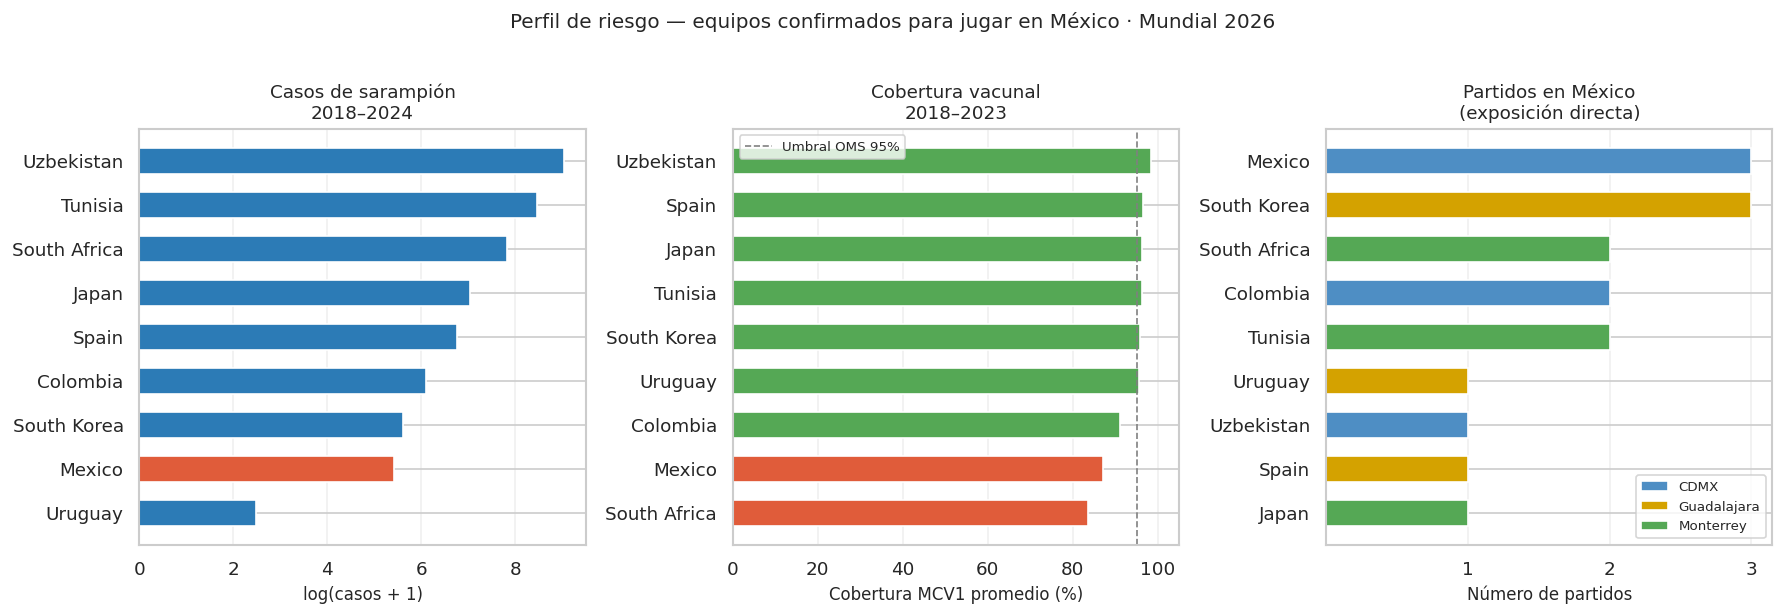

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ciudad_colors = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}

# Panel 1: Casos de sarampión
ax = axes[0]
d = cluster_df.sort_values('total_cases', ascending=True)
colors = ['#e05c3a' if c == 'Mexico' else '#2c7bb6' for c in d['Country']]
ax.barh(d['Country'], np.log1p(d['total_cases']), color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('log(casos + 1)', fontsize=10)
ax.set_title('Casos de sarampión\n2018–2024', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Panel 2: Cobertura MCV1
ax = axes[1]
d2 = cluster_df.sort_values('mcv1_mean', ascending=True)
colors2 = ['#e05c3a' if v < 90 else '#55a855' for v in d2['mcv1_mean']]
ax.barh(d2['Country'], d2['mcv1_mean'], color=colors2, edgecolor='white', height=0.6)
ax.axvline(95, color='gray', linestyle='--', linewidth=1, label='Umbral OMS 95%')
ax.set_xlabel('Cobertura MCV1 promedio (%)', fontsize=10)
ax.set_title('Cobertura vacunal\n2018–2023', fontsize=11)
ax.set_xlim(0, 105)
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)

# Panel 3: Partidos en México por ciudad
ax = axes[2]
d3 = cluster_df.sort_values('partidos_en_mexico', ascending=True)
colors3 = [ciudad_colors.get(c, '#aaaaaa') for c in d3['ciudad_sede']]
ax.barh(d3['Country'], d3['partidos_en_mexico'], color=colors3, edgecolor='white', height=0.6)
ax.set_xlabel('Número de partidos', fontsize=10)
ax.set_title('Partidos en México\n(exposición directa)', fontsize=11)
ax.set_xticks([1, 2, 3])
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor=v, label=k) for k, v in ciudad_colors.items()],
    fontsize=8, loc='lower right'
)

plt.suptitle(
    'Perfil de riesgo — equipos confirmados para jugar en México · Mundial 2026',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('content/reports/figures/riesgo_equipos_mexico.png', dpi=150, bbox_inches='tight')
plt.show()

> **Nota:** la tabla `wc_participation` se construyó en la sección 1.3 a partir
> de los partidos de Qatar 2022. Incluye los 32 países participantes con su
> `asistencia_promedio` como proxy del tamaño de su hinchada.
> Para el Mundial 2026 (48 equipos) actualiza el dataset de Kaggle cuando
> esté disponible, o añade manualmente los equipos nuevos con `clasificado_2026=1`.

---
## 3. Análisis exploratorio de las features de clustering

Antes de aplicar K-Means exploramos visualmente las features para entender:

- **Distribución de cada variable**: ¿están sesgadas? ¿hay outliers?
- **Relación entre vacunación e incidencia**: los dos ejes más importantes del riesgo
- **Correlación entre features**: si dos variables están muy correlacionadas, aportan información redundante al clustering

Con solo 9 equipos los histogramas tienen poco valor estadístico, por eso
los reemplazamos por un **gráfico de barras comparativo** que es más legible
a esta escala. El scatter y el heatmap de correlación sí aplican directamente.

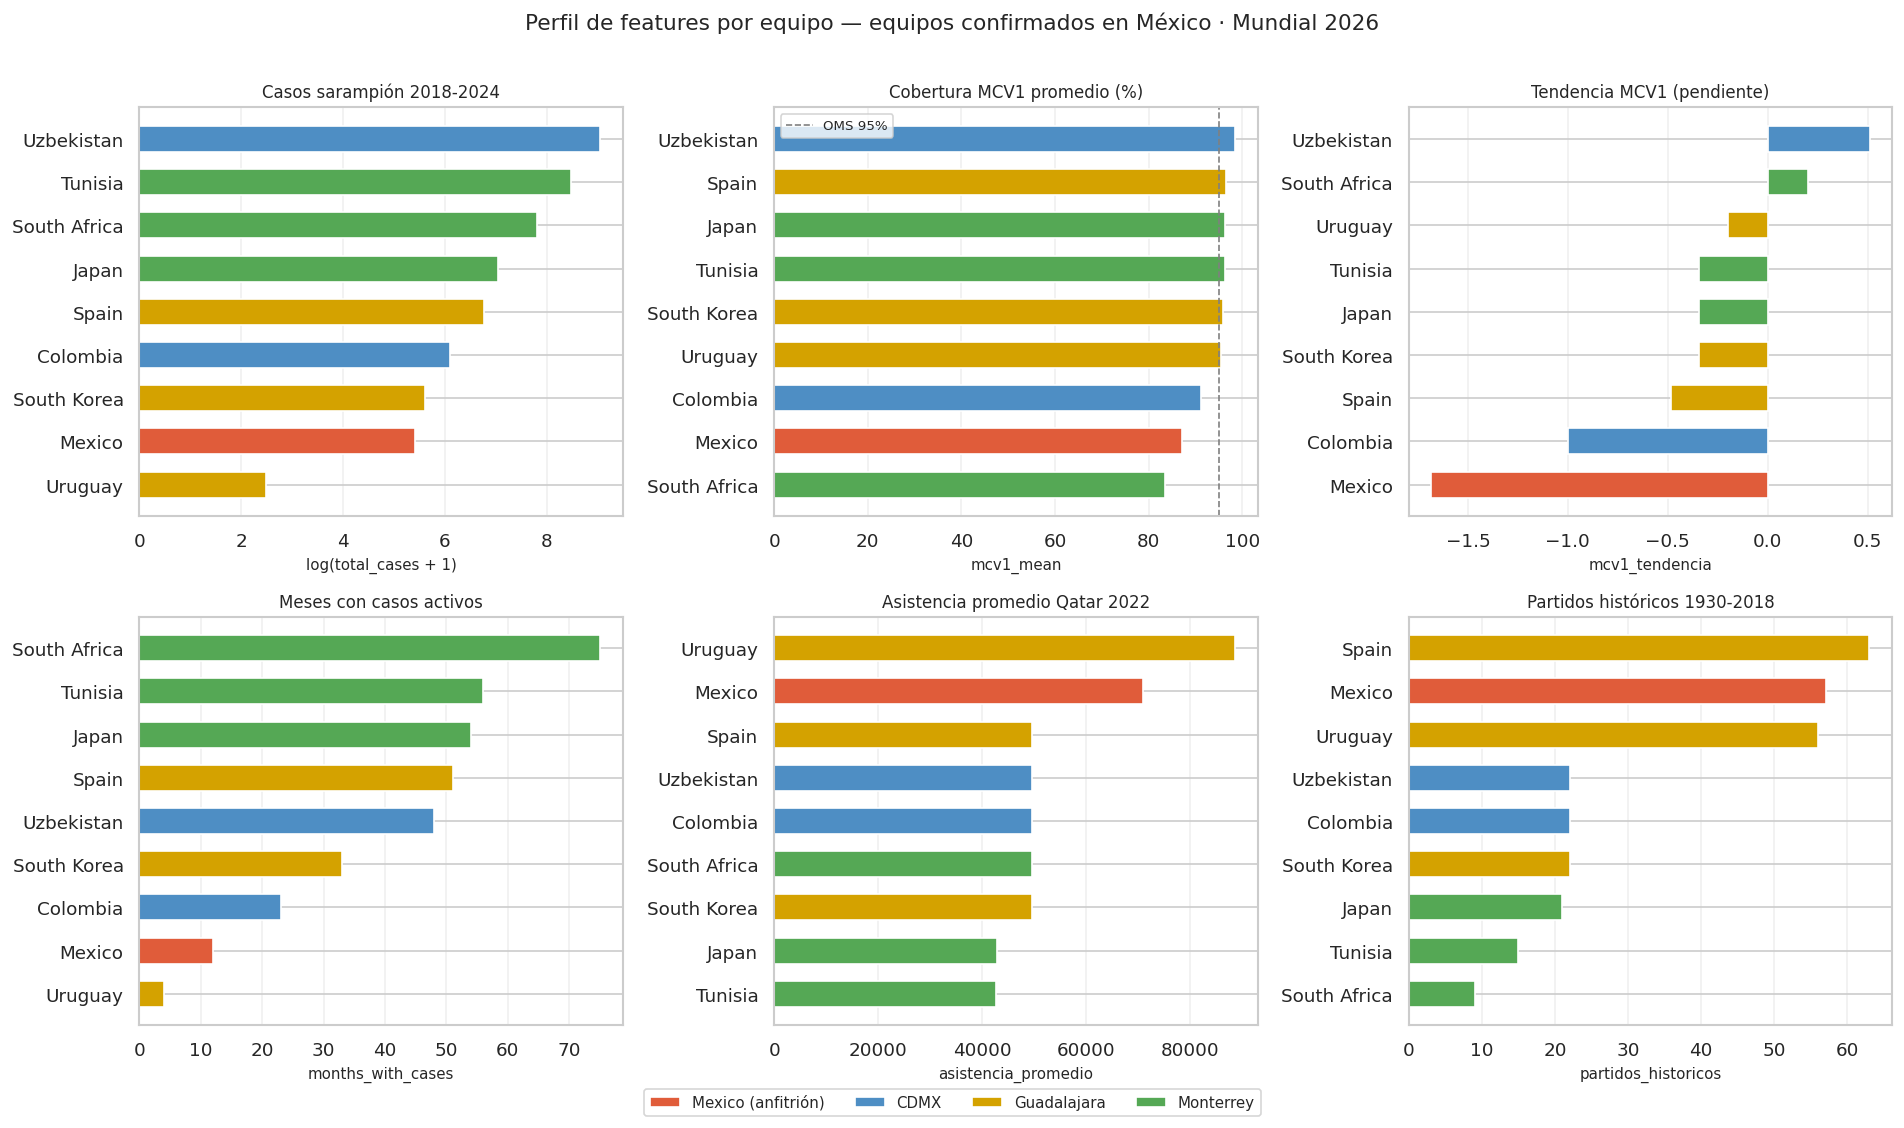

In [ ]:
# Con 9 países los histogramas no aportan — usamos barras comparativas
feature_cols = [
    ('total_cases',        'Casos sarampión 2018-2024',     'log'),
    ('mcv1_mean',          'Cobertura MCV1 promedio (%)',    'linear'),
    ('mcv1_tendencia',     'Tendencia MCV1 (pendiente)',     'linear'),
    ('months_with_cases',  'Meses con casos activos',        'linear'),
    ('asistencia_promedio','Asistencia promedio Qatar 2022', 'linear'),
    ('partidos_historicos','Partidos históricos 1930-2018',  'linear'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (col, label, scale) in zip(axes.flat, feature_cols):
    d = cluster_df.sort_values(col, ascending=True)
    vals = np.log1p(d[col]) if scale == 'log' else d[col]
    xlabel = f'log({col} + 1)' if scale == 'log' else col

    bar_colors = [
        '#e05c3a' if c == 'Mexico' else
        ciudad_colors.get(cluster_df.loc[cluster_df['Country'] == c, 'ciudad_sede'].values[0], '#2c7bb6')
        for c in d['Country']
    ]

    ax.barh(d['Country'], vals, color=bar_colors, edgecolor='white', height=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    # Marcar umbral OMS en cobertura
    if col == 'mcv1_mean':
        ax.axvline(95, color='gray', linestyle='--', linewidth=1, label='OMS 95%')
        ax.legend(fontsize=8)

# Leyenda de colores por ciudad
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_patches = [
    Patch(facecolor='#e05c3a',  label='Mexico (anfitrión)'),
    Patch(facecolor='#4e8ec4',  label='CDMX'),
    Patch(facecolor='#d4a200',  label='Guadalajara'),
    Patch(facecolor='#55a855',  label='Monterrey'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'Perfil de features por equipo — equipos confirmados en México · Mundial 2026',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

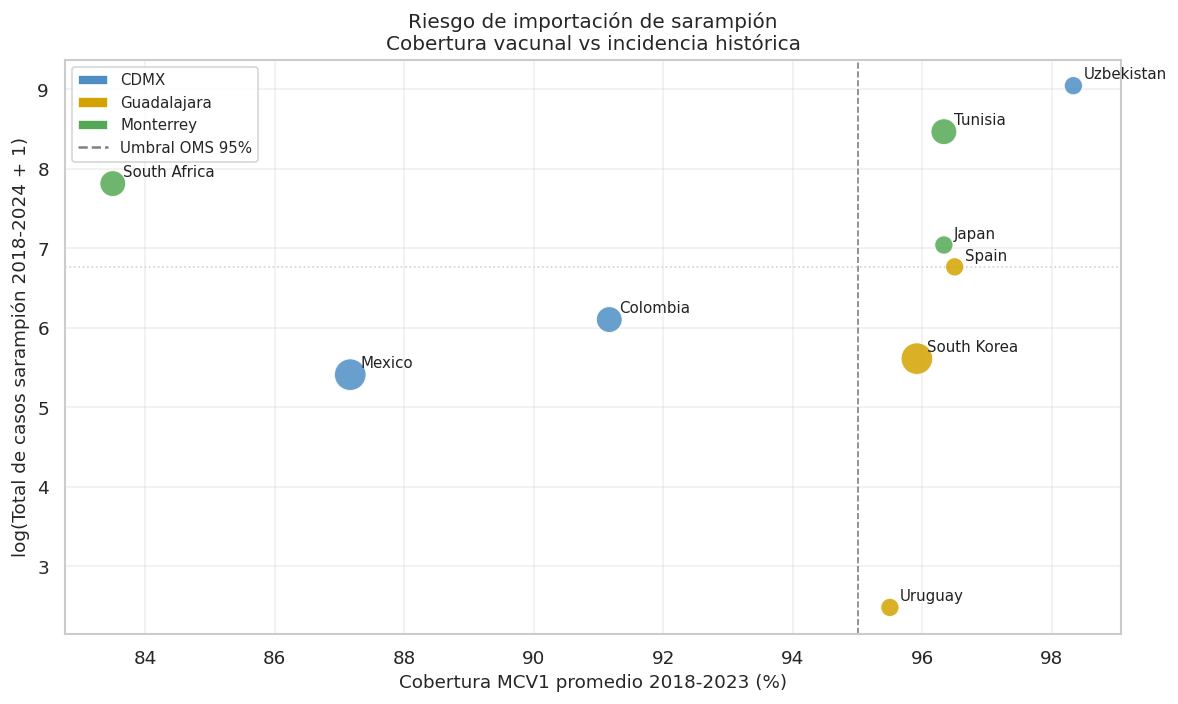

In [ ]:
# Scatter: vacunación vs incidencia — los dos ejes más interpretables del riesgo
fig, ax = plt.subplots(figsize=(10, 6))

ciudad_colors = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}
point_colors = [ciudad_colors.get(c, '#aaaaaa') for c in cluster_df['ciudad_sede']]
sizes = np.clip(cluster_df['partidos_en_mexico'] * 120, 100, 500)

ax.scatter(
    cluster_df['mcv1_mean'],
    np.log1p(cluster_df['total_cases']),
    c=point_colors,
    s=sizes,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.6,
    zorder=3
)

# Etiquetar todos (solo son 9)
for _, row in cluster_df.iterrows():
    ax.annotate(
        row['Country'],
        (row['mcv1_mean'], np.log1p(row['total_cases'])),
        fontsize=9, color='#222',
        xytext=(6, 4), textcoords='offset points'
    )

# Umbral OMS
ax.axvline(95, color='gray', linestyle='--', linewidth=1, label='Umbral OMS (95%)')

# Cuadrantes de riesgo
ax.axhline(
    np.log1p(cluster_df['total_cases'].median()),
    color='lightgray', linestyle=':', linewidth=1
)

ax.set_xlabel('Cobertura MCV1 promedio 2018-2023 (%)', fontsize=11)
ax.set_ylabel('log(Total de casos sarampión 2018-2024 + 1)', fontsize=11)
ax.set_title(
    'Riesgo de importación de sarampión\nCobertura vacunal vs incidencia histórica',
    fontsize=12
)

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=v, label=k) for k, v in ciudad_colors.items()]
legend_patches.append(
    plt.Line2D([0],[0], color='gray', linestyle='--', label='Umbral OMS 95%')
)
ax.legend(handles=legend_patches, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

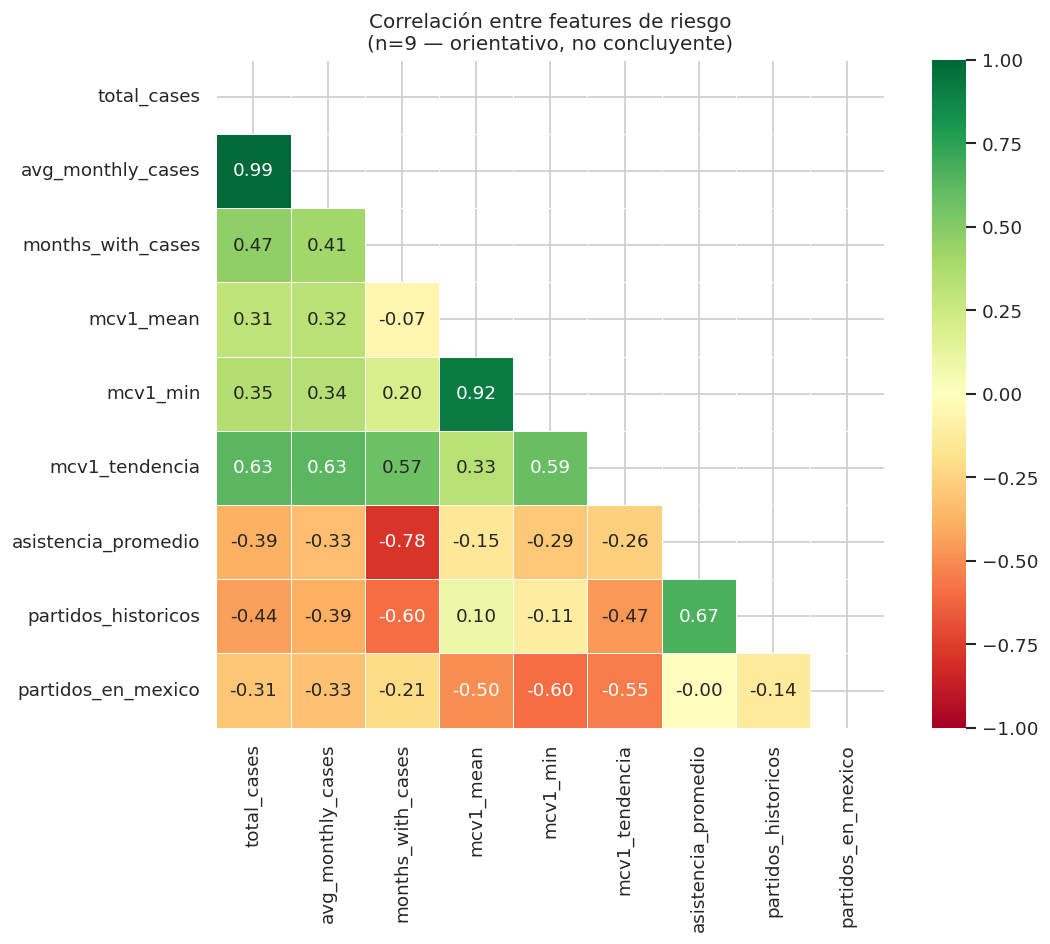

Pares con correlación alta (|r| > 0.7):
          Feature A         Feature B         r
  avg_monthly_cases       total_cases  0.991890
           mcv1_min         mcv1_mean  0.918170
asistencia_promedio months_with_cases -0.782002


In [ ]:
# Correlación entre features numéricas
# Con 9 países la correlación es orientativa, no concluyente — se interpreta con cautela

feature_corr = [
    'total_cases', 'avg_monthly_cases', 'months_with_cases',
    'mcv1_mean', 'mcv1_min', 'mcv1_tendencia',
    'asistencia_promedio', 'partidos_historicos', 'partidos_en_mexico'
]

corr = cluster_df[feature_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, square=True
)
ax.set_title(
    'Correlación entre features de riesgo\n'
    '(n=9 — orientativo, no concluyente)',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Imprimir pares con alta correlación (|r| > 0.7) para decisión de features
print("Pares con correlación alta (|r| > 0.7):")
corr_pairs = (
    corr.where(mask == False)
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'r']
corr_pairs = corr_pairs[corr_pairs['r'].abs() > 0.7].sort_values('r', ascending=False)
print(corr_pairs.to_string(index=False) if len(corr_pairs) > 0 else "Ninguno")

---
## 4. Preprocesamiento para clustering

Antes de aplicar el algoritmo de clustering (K-Means), necesitamos preparar nuestras variables numéricas. Este paso es crucial y consta de tres fases:

Transformación Logarítmica (log1p): Variables como el total de casos (total_cases) suelen tener una distribución muy sesgada (la mayoría de países tienen pocos casos, pero unos pocos tienen brotes masivos). Aplicar el logaritmo suaviza estas diferencias extremas.

Imputación de Nulos: Es muy común que falten datos históricos de vacunación para algunos países. Usaremos la mediana para rellenar estos huecos y evitar que el modelo falle.

Estandarización (StandardScaler): K-Means agrupa basándose en distancias (euclidianas). Si no escalamos, una variable con valores de miles (como los casos) dominará completamente a una variable de porcentajes (como la cobertura de vacunación). Estandarizar asegura que todas las variables pesen lo mismo, centrando su media en 0 y su desviación estándar en 1.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# 1. Selección de features para el clustering
# Excluimos variables redundantes o con demasiados nulos irreparables (ej. mcv1_std)
cluster_features = [
    'total_cases',       # Volumen total histórico de casos
    'months_with_cases', # Persistencia del brote (meses con >0 casos)
    'mcv1_mean',         # Cobertura promedio de vacunación
    'mcv1_min',          # Peor año de cobertura (indicador de vulnerabilidad)
    'mcv1_tendencia',    # ¿Mejora o empeora la vacunación? (Pendiente)
]

# Copia de seguridad para no alterar el DataFrame original
X = cluster_df[cluster_features].copy()

# 2. Transformación para corregir el sesgo (Skewness)
# Usamos log1p (logaritmo de x + 1) para manejar correctamente los ceros
X['total_cases']       = np.log1p(X['total_cases'])
X['months_with_cases'] = np.log1p(X['months_with_cases'])

# 3. Imputación de valores nulos
# Rellenamos los datos faltantes con la mediana de cada columna
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 4. Estandarización
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_imputed)

# Reconstruimos el DataFrame con índices y columnas para mantener la trazabilidad
X_scaled = pd.DataFrame(X_scaled_array, columns=cluster_features, index=cluster_df.index)

# Verificación de calidad del preprocesamiento
print('--- Calidad del Preprocesamiento ---')
print('Media de cada feature (debe ser ~0):')
print(X_scaled.mean().round(4))
print('\nDesviación estándar (debe ser ~1):')
print(X_scaled.std().round(4))
print(f'\nValores nulos restantes: {X_scaled.isna().sum().sum()}')


--- Calidad del Preprocesamiento ---
Media de cada feature (debe ser ~0):
total_cases          0.0
months_with_cases   -0.0
mcv1_mean           -0.0
mcv1_min            -0.0
mcv1_tendencia      -0.0
dtype: float64

Desviación estándar (debe ser ~1):
total_cases          1.0607
months_with_cases    1.0607
mcv1_mean            1.0607
mcv1_min             1.0607
mcv1_tendencia       1.0607
dtype: float64

Valores nulos restantes: 0


---
## 5. K-Means — Método 1 de aprendizaje no supervisado

Una vez que nuestros datos están limpios y estandarizados, procedemos a aplicar **K-Means** para agrupar a los países según su riesgo. El primer gran desafío del aprendizaje no supervisado es descubrir cuántos grupos (clusters, $k$) existen realmente en los datos, ya que no tenemos una etiqueta previa que nos lo indique.

### 5.1 Selección del número de clusters (Elbow + Silhouette)

Para encontrar el valor óptimo de $k$, calculamos el modelo múltiples veces (desde $k=2$ hasta $k=10$) y evaluamos su rendimiento usando dos métodos visuales y matemáticos:

* **Método del Codo (Elbow Method):** Evalúa la **Inercia** (la suma de las distancias al cuadrado de cada punto a su centroide). Buscamos el punto de inflexión (el "codo") donde añadir más clusters ya no reduce significativamente la inercia.
* **Coeficiente de Silhouette (Silhouette Score):** Mide qué tan similar es un objeto a su propio cluster en comparación con otros clusters. Varía de $-1$ a $1$.
    * Un valor más alto indica clusters mejor definidos y separados.
    * Es nuestra métrica principal para desempatar y elegir el $k$ definitivo.

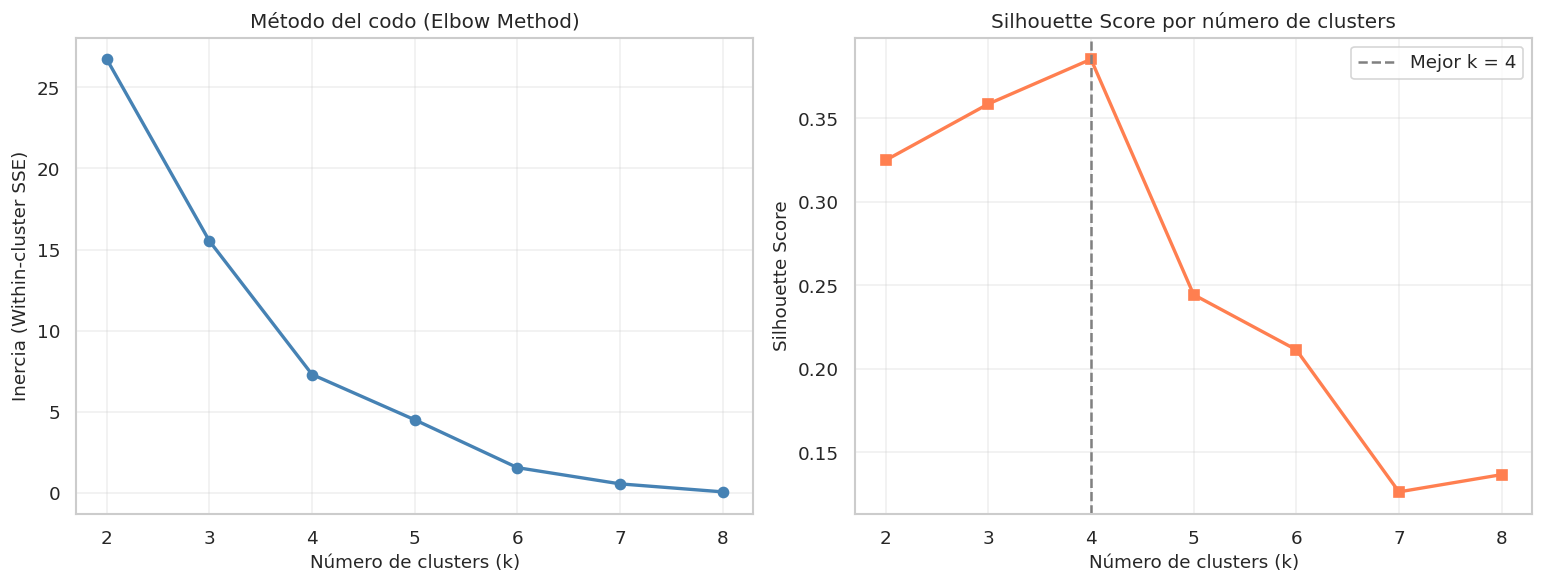

Mejor k según Silhouette: 4 (score = 0.385)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Obtenemos la cantidad de muestras (filas) en nuestros datos
n_samples = X_scaled.shape[0]

# El número máximo de clusters para silhouette debe ser al menos 1 menos que n_samples
# Limitamos a un máximo de 10 clusters (o menos si hay poquitos datos) para evitar el ValueError
max_k = min(10, n_samples - 1)

# Rango dinámico y seguro de clusters a evaluar
k_range = range(2, max_k + 1)
inertias = []
silhouettes = []

# Iteramos sobre cada posible valor de k
for k in k_range:
    # n_init=20 asegura que el algoritmo pruebe 20 inicios aleatorios distintos
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)

    # Guardamos las métricas para graficarlas después
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Configuración de la gráfica (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Gráfica del Método del Codo (Elbow)
ax1.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Número de clusters (k)', fontsize=11)
ax1.set_ylabel('Inercia (Within-cluster SSE)', fontsize=11)
ax1.set_title('Método del codo (Elbow Method)', fontsize=12)
ax1.grid(True, alpha=0.3)

# 2. Gráfica de Silhouette
ax2.plot(list(k_range), silhouettes, 's-', color='coral', linewidth=2)
ax2.set_xlabel('Número de clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score por número de clusters', fontsize=12)
ax2.grid(True, alpha=0.3)

# Identificar y marcar automáticamente el mejor k según silhouette
best_k_sil = list(k_range)[np.argmax(silhouettes)]
ax2.axvline(best_k_sil, color='gray', linestyle='--', label=f'Mejor k = {best_k_sil}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Mejor k según Silhouette: {best_k_sil} (score = {max(silhouettes):.3f})')



### 5.2 Ajustar K-Means con el $k$ seleccionado

Una vez analizados los gráficos de **Codo** (Elbow) y **Silhouette**, elegimos el número final de clusters ($k$) para entrenar nuestro modelo definitivo.

En esta etapa:
* Ejecutamos el algoritmo **K-Means** con el hiperparámetro $k$ optimizado.
* El modelo asignará una **etiqueta de cluster** a cada país basándose en la proximidad a los centroides calculados.
* Estas etiquetas nos permitirán segmentar el dataset original para realizar análisis comparativos entre los grupos de riesgo identificados.

In [ ]:
# Usamos el k que sugirió el análisis anterior (best_k_sil)
# Puedes cambiar este valor manualmente (ej. K_FINAL = 4) si el contexto epidemiológico
# justifica una agrupación diferente a la puramente matemática.
K_FINAL = best_k_sil

# Entrenamos el modelo final con parámetros robustos
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=30, max_iter=1000)

# Asignamos la etiqueta del cluster a nuestro DataFrame original
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

print(f'--- Resultados del modelo K-Means Final (k={K_FINAL}) ---')
print(f'Silhouette Score global: {silhouette_score(X_scaled, cluster_df["cluster"]):.3f}')
print(f'Inercia total: {km_final.inertia_:.1f}')
print('\nDistribución de países por cluster (¿Cuántos países hay en cada grupo?):')
print(cluster_df['cluster'].value_counts().sort_index())


--- Resultados del modelo K-Means Final (k=4) ---
Silhouette Score global: 0.385
Inercia total: 7.3

Distribución de países por cluster (¿Cuántos países hay en cada grupo?):
cluster
0    2
1    5
2    1
3    1
Name: count, dtype: int64


### 5.3 Interpretación de clusters

Ahora que cada país tiene asignado un grupo numérico, necesitamos entender qué significa cada cluster en la **vida real**. Para lograrlo, realizamos un análisis de los perfiles resultantes:

1.  **Agrupación de Datos:** Agrupamos los datos originales (sin escalar) utilizando las etiquetas generadas por el modelo.
2.  **Cálculo de Promedios:** Calculamos el promedio (o la mediana) de cada variable para cada grupo.
3.  **Perfilamiento:** Esto nos permitirá identificar las características distintivas de cada segmento, por ejemplo:
    * **Grupo de Alto Riesgo:** Países con altos casos y baja cobertura de vacunación.
    * **Grupo Controlado:** Países con alta vacunación y pocos casos activos.
    * **Grupo en Transición:** Países con métricas intermedias.

> **Nota:** Es fundamental volver a los datos originales para la interpretación, ya que los valores estandarizados (con media 0) son difíciles de traducir a términos de salud pública.

In [ ]:
# Perfil promedio de cada cluster (en escala original, no escalada)
profile_cols = ['total_cases', 'months_with_cases', 'mcv1_mean', 'mcv1_min', 'mcv1_tendencia']

cluster_profile = (
    cluster_df
    .groupby('cluster')[profile_cols]
    .mean()
    .round(2)
)

# Agregar conteo de países por cluster
cluster_profile['n_paises'] = cluster_df.groupby('cluster').size()

# Agregar la suma de países que van a asistir al Mundial 2026 dentro de cada cluster
# (Asume que la columna 'clasificado_2026' existe y contiene valores 0/1)
if 'clasificado_2026' in cluster_df.columns:
    cluster_profile['paises_wc2026'] = cluster_df.groupby('cluster')['clasificado_2026'].sum()

print('--- Perfil promedio por cluster ---')
print(cluster_profile.to_string())


--- Perfil promedio por cluster ---
         total_cases  months_with_cases  mcv1_mean  mcv1_min  mcv1_tendencia  n_paises  paises_wc2026
cluster                                                                                              
0              335.0               17.5      89.17      79.5           -1.34         2              2
1             3104.0               48.4      96.68      94.7           -0.20         5              5
2               11.0                4.0      95.50      93.0           -0.20         1              1
3             2475.0               75.0      83.50      80.0            0.20         1              1


Para hacer la comparación más visual e intuitiva, generaremos un **Mapa de Calor (Heatmap)**.

* **Uso de Datos:** En este gráfico utilizaremos los valores estandarizados (`X_scaled`).
* **Ventaja:** Esto nos permite comparar todas las variables en una misma escala visual, identificando rápidamente qué clusters tienen valores por encima o por debajo de la media global para cada característica.
* **Interpretación:** Los colores intensos nos ayudarán a detectar patrones de riesgo o éxito en las políticas de salud de manera inmediata.

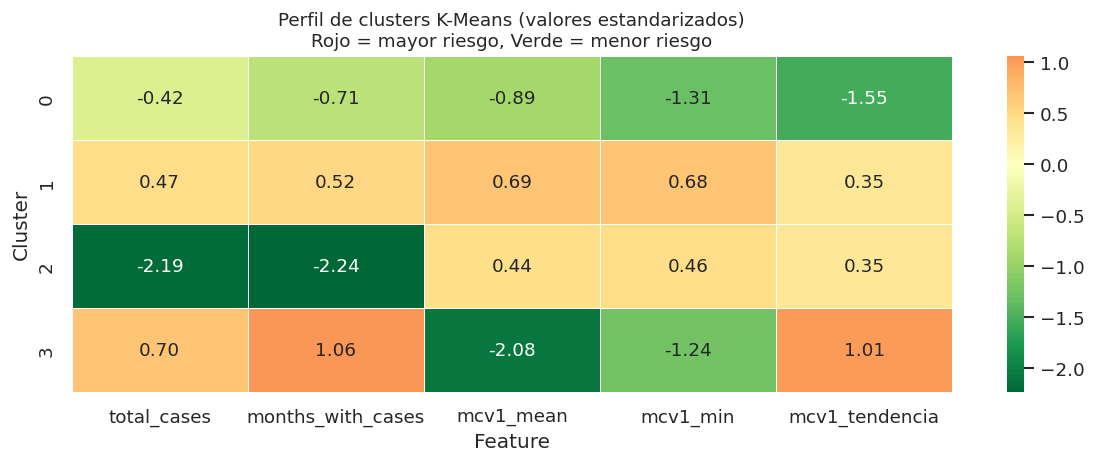

In [ ]:
import seaborn as sns
import pandas as pd

# Heatmap del perfil de clusters (valores estandarizados para comparar escala)
cluster_scaled_profile = (
    pd.DataFrame(X_scaled, index=cluster_df.index, columns=cluster_features)
    .assign(cluster=cluster_df['cluster'])
    .groupby('cluster')[cluster_features]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    cluster_scaled_profile,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Perfil de clusters K-Means (valores estandarizados)\nRojo = mayor riesgo, Verde = menor riesgo', fontsize=11)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()



Finalmente, basándonos en el perfil visualizado en el mapa de calor, traducimos los números de los clusters a **etiquetas de riesgo** que podamos interpretar y analizar desde un punto de vista epidemiológico.

Este paso es el puente entre los datos y la toma de decisiones:
* **Categorización:** Asignamos nombres descriptivos (ej. *Riesgo Extremo*, *Resiliencia Alta*, *Vigilancia Activa*).
* **Foco en el Mundial 2026:** Prestamos especial atención a los países que asistirán al torneo, evaluando cómo su perfil de riesgo podría impactar la seguridad sanitaria del evento.
* **Acción:** Estas etiquetas permiten priorizar recursos y diseñar protocolos específicos para cada grupo de naciones.

In [ ]:
# -----------------------------------------------------------------------
# IMPORTANTE: después de ver el perfil (Heatmap y promedios), asigna
# etiquetas interpretables a cada cluster.
# ¡Ajusta los números (0, 1, 2...) según los resultados de tu ejecución!
# -----------------------------------------------------------------------
cluster_labels = {
    0: 'Riesgo muy alto',     # muchos casos, vacunación baja
    1: 'Riesgo moderado',     # casos medios, vacunación variable
    2: 'Riesgo bajo',         # pocos casos, buena vacunación
    3: 'Riesgo muy bajo',     # casi sin casos, >95% vacunación
}

# Mapeamos las etiquetas al DataFrame
cluster_df['riesgo_label'] = cluster_df['cluster'].map(cluster_labels)

# Verificamos si existe la columna de clasificados. Si no, simulamos una
# de forma temporal para que el análisis de código no falle.
if 'clasificado_2026' not in cluster_df.columns:
    print("⚠️ Aviso: La columna 'clasificado_2026' no se encontró.")
    print("Creando una columna de prueba temporal con los países anfitriones...\n")
    # Asegúrate de importar la columna real desde tu dataset original (ej. haciendo un merge)
    anfitriones = ['Mexico', 'United States of America', 'Canada', 'USA']
    # Si 'Country' es el índice de tu DF, usamos .index, si no, lo buscamos en columnas
    paises = cluster_df['Country'] if 'Country' in cluster_df.columns else cluster_df.index
    cluster_df['clasificado_2026'] = paises.isin(anfitriones).astype(int)

# Visualizamos qué países clasificados al Mundial cayeron en cada nivel de riesgo
print('Países clasificados al Mundial 2026 por cluster:')

# Si 'Country' es el índice, lo convertimos a columna temporalmente para mostrarlo bien
df_display = cluster_df.copy()
if 'Country' not in df_display.columns:
    df_display = df_display.reset_index(names='Country')

wc_by_cluster = (
    df_display[df_display['clasificado_2026'] == 1]
    [['Country', 'cluster', 'riesgo_label', 'total_cases', 'mcv1_mean']]
    .sort_values(['cluster', 'total_cases'], ascending=[True, False])
)

print(wc_by_cluster.to_string(index=False))


Países clasificados al Mundial 2026 por cluster:
     Country  cluster    riesgo_label  total_cases  mcv1_mean
    Colombia        0 Riesgo muy alto        447.0  91.166667
      Mexico        0 Riesgo muy alto        223.0  87.166667
  Uzbekistan        1 Riesgo moderado       8480.0  98.333333
     Tunisia        1 Riesgo moderado       4756.0  96.333333
       Japan        1 Riesgo moderado       1143.0  96.333333
       Spain        1 Riesgo moderado        868.0  96.500000
 South Korea        1 Riesgo moderado        273.0  95.916667
     Uruguay        2     Riesgo bajo         11.0  95.500000
South Africa        3 Riesgo muy bajo       2475.0  83.500000


### 5.4 Visualización en 2D con PCA

Dado que manejamos múltiples variables de riesgo (cobertura vacunal, número de casos, tendencias, etc.), resulta imposible visualizar los grupos en un gráfico bidimensional tradicional. Para resolverlo, aplicamos el **Análisis de Componentes Principales (PCA)**.

* **Condensación de Datos:** El PCA nos permite comprimir toda la información multidimensional en solo dos ejes: el **Componente Principal 1 (PC1)** y el **Componente Principal 2 (PC2)**.
* **Graficación de Clusters:** Esto facilita la creación de un *scatter plot* donde cada punto es un país y los colores representan los clusters identificados por K-Means.
* **Análisis de Loadings (Cargas):** No solo veremos los grupos, sino que entenderemos mediante los *loadings* qué variables (ej. vacunación vs. mortalidad) tuvieron mayor peso para separar a los países en el espacio 2D.

> **Propósito:** Maximizar la varianza explicada para que la separación visual sea lo más fiel posible a la realidad de los datos originales.

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Inicializamos y ajustamos PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Revisamos cuánta varianza (información original) conservamos con estos 2 ejes
var_explained = pca.explained_variance_ratio_
print('--- Varianza Explicada por PCA ---')
print(f'Varianza explicada por PC1: {var_explained[0]*100:.1f}%')
print(f'Varianza explicada por PC2: {var_explained[1]*100:.1f}%')
print(f'Total (2 componentes): {sum(var_explained)*100:.1f}%')

# Analizamos qué variables originales dominan cada componente (Loadings)
loading_df = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=['PC1', 'PC2']
).round(3)

print('\n--- Loadings de PCA (Qué variables pesan más en cada eje) ---')
print(loading_df)


--- Varianza Explicada por PCA ---
Varianza explicada por PC1: 52.5%
Varianza explicada por PC2: 33.6%
Total (2 componentes): 86.2%

--- Loadings de PCA (Qué variables pesan más en cada eje) ---
                     PC1    PC2
total_cases        0.418 -0.517
months_with_cases  0.428 -0.513
mcv1_mean          0.402  0.529
mcv1_min           0.501  0.435
mcv1_tendencia     0.479  0.012


Para interpretar mejor la separación que logró **K-Means**, visualizamos los países en un plano 2D utilizando los dos componentes principales generados por el PCA.

* **Visualización del Espacio de Riesgo:** Este gráfico nos permite ver cómo el algoritmo ha "agrupado" a países con perfiles epidemiológicos similares, basándose en la varianza capturada por PC1 y PC2.
* **Foco Estratégico:** Destacaremos de forma especial a los países que ya han **clasificado al Mundial 2026**.
* **Objetivo:** Esto facilita la identificación instantánea de la categoría de riesgo en la que se encuentran las selecciones participantes, permitiendo un análisis comparativo directo de la situación de los países que moverán mayores flujos de personas durante el evento.

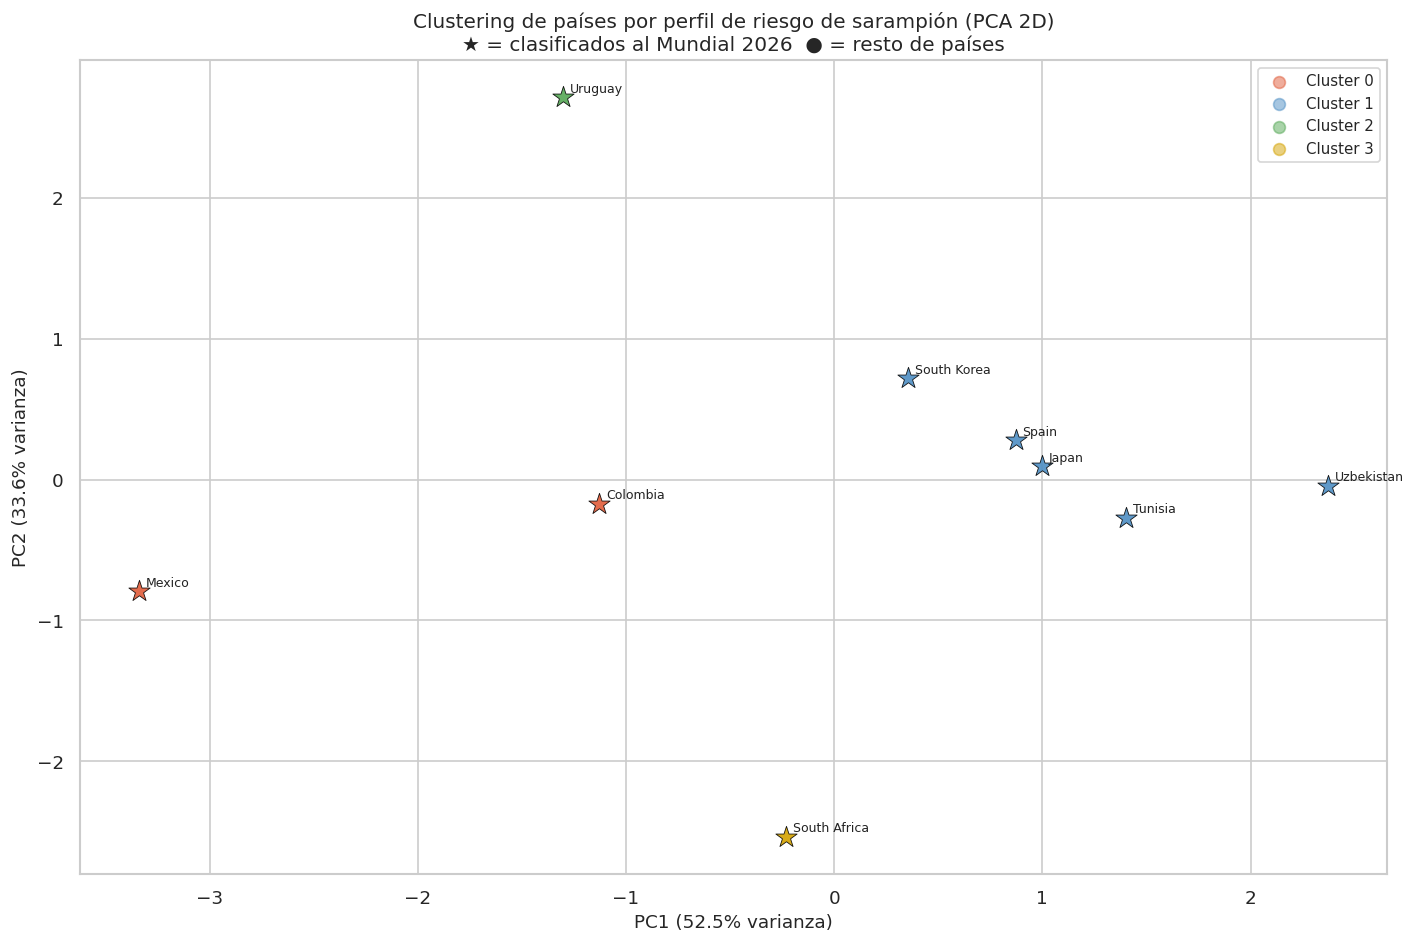

In [ ]:
# Colores por cluster y marcador para países del Mundial
palette = ['#e05c3a', '#4e8ec4', '#55a855', '#d4a200', '#8e6dbd', '#cc6699']

fig, ax = plt.subplots(figsize=(12, 8))

for cl in sorted(cluster_df['cluster'].unique()):
    mask = cluster_df['cluster'] == cl
    wc_mask = mask & (cluster_df['clasificado_2026'] == 1)
    non_wc_mask = mask & (cluster_df['clasificado_2026'] == 0)

    # Gráfico para los países no clasificados
    ax.scatter(
        X_pca[non_wc_mask, 0], X_pca[non_wc_mask, 1],
        color=palette[cl], alpha=0.5, s=50, marker='o',
        label=f'Cluster {cl}'
    )
    # Gráfico destacado para los países Clasificados al Mundial 2026
    ax.scatter(
        X_pca[wc_mask, 0], X_pca[wc_mask, 1],
        color=palette[cl], alpha=0.9, s=180, marker='*',
        edgecolors='black', linewidths=0.5
    )

# Añadir las etiquetas con el nombre de los países clasificados
wc_idx = cluster_df['clasificado_2026'] == 1
for i, (idx, row) in enumerate(cluster_df[wc_idx].iterrows()):
    ax.annotate(
        row['Country'], (X_pca[cluster_df.index.get_loc(idx), 0],
                          X_pca[cluster_df.index.get_loc(idx), 1]),
        fontsize=7.5, xytext=(4, 3), textcoords='offset points', color='#222'
    )

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title(
    'Clustering de países por perfil de riesgo de sarampión (PCA 2D)\n'
    '★ = clasificados al Mundial 2026  ● = resto de países',
    fontsize=12
)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Clustering Jerárquico — Método 2 de aprendizaje no supervisado

El **Clustering Jerárquico** nos aporta una perspectiva adicional y complementaria al análisis de K-Means. A diferencia de este último, el método jerárquico presenta características distintivas:

* **Sin un $k$ inicial:** No requiere especificar el número de clusters ($k$) a priori, permitiendo que la estructura surja de los datos de forma orgánica.
* **Estructura de Dendrograma:** Genera un diagrama de árbol (dendrograma) que ilustra las relaciones de proximidad.
* **Grados de Similitud:** Facilita la comprensión de la jerarquía subyacente; podemos ver qué países son "primos hermanos" en términos epidemiológicos antes de que se agrupen en categorías más grandes.
* **Validación:** Nos sirve para confirmar si las agrupaciones de K-Means son consistentes con la estructura natural de los datos.

> **Ventaja Clave:** El dendrograma permite decidir visualmente dónde "cortar" el árbol para definir los grupos, basándonos en las distancias verticales más largas sin intersecciones.

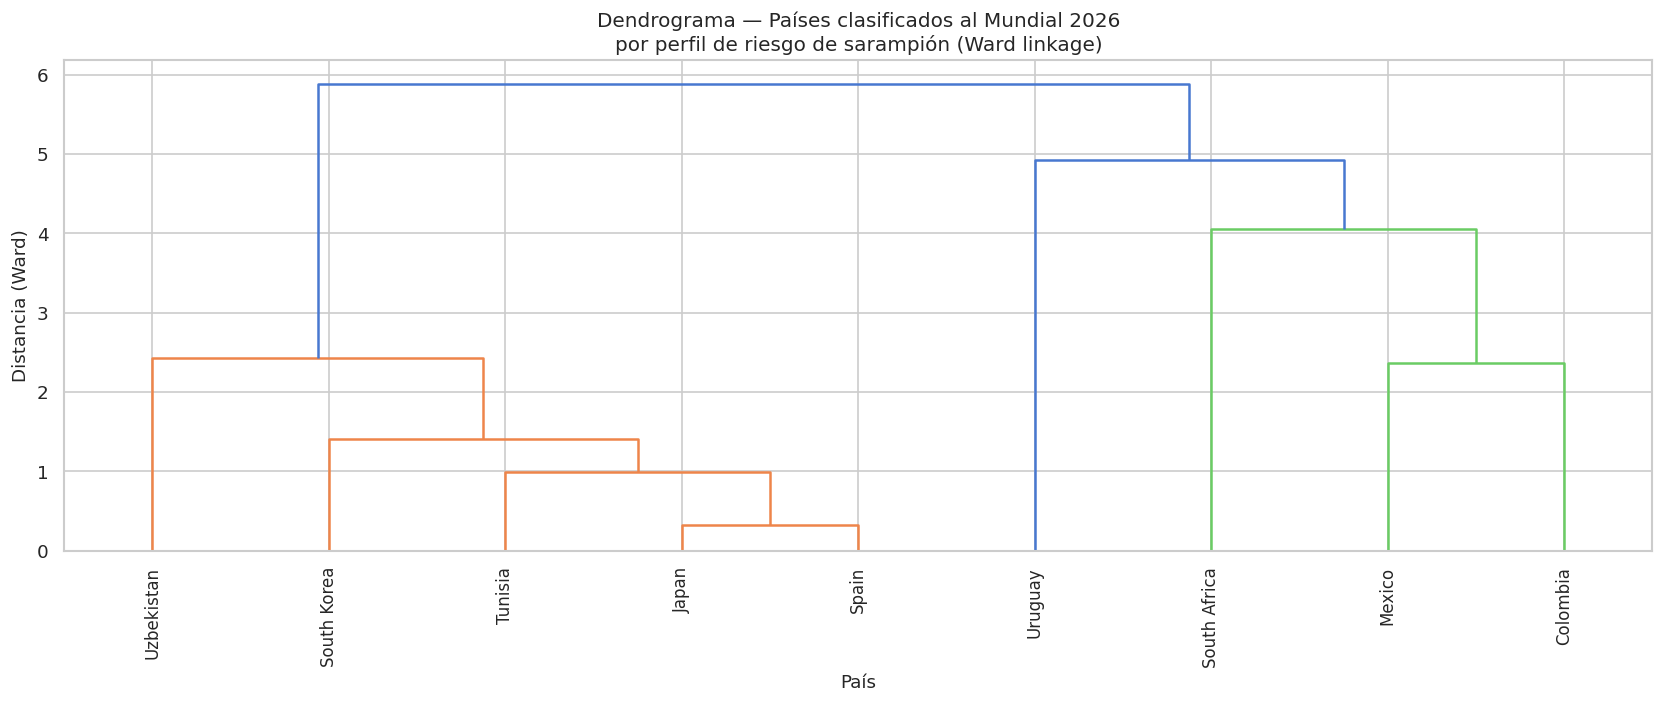

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Calcular linkage (método Ward minimiza la varianza intra-cluster)
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Solo mostrar países del Mundial en el dendrograma (más legible)
wc_df = cluster_df[cluster_df['clasificado_2026'] == 1].copy()
X_wc = X_scaled.loc[wc_df.index]
Z_wc = linkage(X_wc, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z_wc,
    labels=wc_df['Country'].values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7 * max(Z_wc[:, 2]),
    ax=ax
)
ax.set_title(
    'Dendrograma — Países clasificados al Mundial 2026\n'
    'por perfil de riesgo de sarampión (Ward linkage)',
    fontsize=12
)
ax.set_xlabel('País', fontsize=11)
ax.set_ylabel('Distancia (Ward)', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# Cortar el dendrograma con el mismo k del K-Means
wc_df = wc_df.copy()
wc_df['cluster_jerarquico'] = fcluster(Z_wc, t=K_FINAL, criterion='maxclust')

# Ver cómo se distribuyen los países en el clustering jerárquico
print(f'Distribución de países del Mundial por cluster jerárquico (k={K_FINAL}):')
for cl, grp in wc_df.groupby('cluster_jerarquico'):
    print(f'\nCluster {cl} ({len(grp)} países):')
    print(
        grp[['Country', 'total_cases', 'mcv1_mean']]
        .sort_values('total_cases', ascending=False)
        .to_string(index=False)
    )


Distribución de países del Mundial por cluster jerárquico (k=4):

Cluster 1 (5 países):
    Country  total_cases  mcv1_mean
 Uzbekistan       8480.0  98.333333
    Tunisia       4756.0  96.333333
      Japan       1143.0  96.333333
      Spain        868.0  96.500000
South Korea        273.0  95.916667

Cluster 2 (2 países):
 Country  total_cases  mcv1_mean
Colombia        447.0  91.166667
  Mexico        223.0  87.166667

Cluster 3 (1 países):
     Country  total_cases  mcv1_mean
South Africa       2475.0       83.5

Cluster 4 (1 países):
Country  total_cases  mcv1_mean
Uruguay         11.0       95.5


In [ ]:
# Comparar K-Means vs jerárquico para los países del Mundial
comparacion = wc_df[['Country', 'cluster', 'cluster_jerarquico', 'total_cases', 'mcv1_mean']].copy()
comparacion.columns = ['País', 'Cluster K-Means', 'Cluster Jerárquico', 'Casos 2018-24', 'MCV1 promedio']

# Concordancia entre métodos
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(wc_df['cluster'], wc_df['cluster_jerarquico'])
print(f'\nAdjusted Rand Index (concordancia entre métodos): {ari:.3f}')
print('(1.0 = perfecta concordancia, 0 = aleatoria)\n')

print(comparacion.sort_values('Casos 2018-24', ascending=False).to_string(index=False))


Adjusted Rand Index (concordancia entre métodos): 1.000
(1.0 = perfecta concordancia, 0 = aleatoria)

        País  Cluster K-Means  Cluster Jerárquico  Casos 2018-24  MCV1 promedio
  Uzbekistan                1                   1         8480.0      98.333333
     Tunisia                1                   1         4756.0      96.333333
South Africa                3                   3         2475.0      83.500000
       Japan                1                   1         1143.0      96.333333
       Spain                1                   1          868.0      96.500000
    Colombia                0                   2          447.0      91.166667
 South Korea                1                   1          273.0      95.916667
      Mexico                0                   2          223.0      87.166667
     Uruguay                2                   4           11.0      95.500000


---
## 7. Análisis de riesgo para México: ¿quién viene al Mundial?

En esta fase final, pasamos de la segmentación teórica a la **evaluación de impacto directo**. Para ello, cruzamos los resultados de nuestros modelos de aprendizaje no supervisado con variables de movilidad internacional.

* **Integración de Datos:** Combinamos los clusters de riesgo epidemiológico con la información de los **flujos de pasajeros** internacionales previstos.
* **Estimación de Importación:** El objetivo es calcular el riesgo potencial de importación de casos hacia las **ciudades sede** (Ciudad de México, Guadalajara y Monterrey).
* **Priorización:** Al identificar qué países de "Alto Riesgo" tienen mayor volumen de viajes hacia México, podemos emitir recomendaciones específicas para la vigilancia sanitaria en aeropuertos y zonas de alta concentración de aficionados.

> **Indicador Clave:** El riesgo no solo depende del cluster del país de origen, sino de la probabilidad de interacción (volumen de viajeros) con la población local en las sedes mundialistas.

In [ ]:
# Resumen de países clasificados al Mundial por nivel de riesgo
# Usando el cluster K-Means como base

# Calcular score de riesgo compuesto (manual, basado en el perfil del cluster):
# Alto riesgo = muchos casos + baja vacunación
cluster_df['score_riesgo'] = (
    np.log1p(cluster_df['total_cases']) * (100 - cluster_df['mcv1_mean']) / 100
)

# Normalizar a 0-10
min_r = cluster_df['score_riesgo'].min()
max_r = cluster_df['score_riesgo'].max()
cluster_df['score_riesgo_norm'] = (
    (cluster_df['score_riesgo'] - min_r) / (max_r - min_r) * 10
).round(2)

# Filtrar países del Mundial
riesgo_mundial = (
    cluster_df[cluster_df['clasificado_2026'] == 1]
    # Usa 'Country' temporalmente si 'ISO3' no está disponible en este punto
    [['Country', 'cluster', 'total_cases', 'mcv1_mean', 'score_riesgo_norm']]
    .sort_values('score_riesgo_norm', ascending=False)
)

print('Top 20 países clasificados al Mundial por score de riesgo de sarampión:')
print(riesgo_mundial.head(20).to_string(index=False))


Top 20 países clasificados al Mundial por score de riesgo de sarampión:
     Country  cluster  total_cases  mcv1_mean  score_riesgo_norm
South Africa        3       2475.0  83.500000              10.00
      Mexico        0        223.0  87.166667               4.95
    Colombia        0        447.0  91.166667               3.63
     Tunisia        1       4756.0  96.333333               1.69
       Japan        1       1143.0  96.333333               1.24
       Spain        1        868.0  96.500000               1.06
 South Korea        1        273.0  95.916667               1.00
  Uzbekistan        1       8480.0  98.333333               0.33
     Uruguay        2         11.0  95.500000               0.00


### 7.1 Visualización del Ranking de Riesgo de Importación

Para hacer este análisis más visual y fácil de interpretar, graficaremos este "**Top**" de países clasificados al Mundial 2026 utilizando un **gráfico de barras horizontales**.

Este gráfico integrará múltiples dimensiones de análisis en una sola vista:

* **Longitud de la Barra (Eje X):** Representará el **score de riesgo compuesto**. A mayor longitud, mayor es el riesgo potencial de importación de casos desde ese país hacia México.
* **Color de la Barra:** Indicará el **cluster de K-Means** al que pertenece el país, facilitando la identificación rápida de grupos homogéneos (ej. Rojo para Riesgo Alto, Verde para Riesgo Bajo).
* **Etiqueta Visual:** Añadiremos un indicador textual o numérico para recordar el nivel de **cobertura de vacunación promedio** de cada país, aportando contexto crucial sobre su vulnerabilidad inmunológica.

> **Objetivo:** Proporcionar a las autoridades de salud una herramienta visual clara para priorizar las medidas de vigilancia sanitaria sobre las delegaciones y aficiones de mayor riesgo potencial.

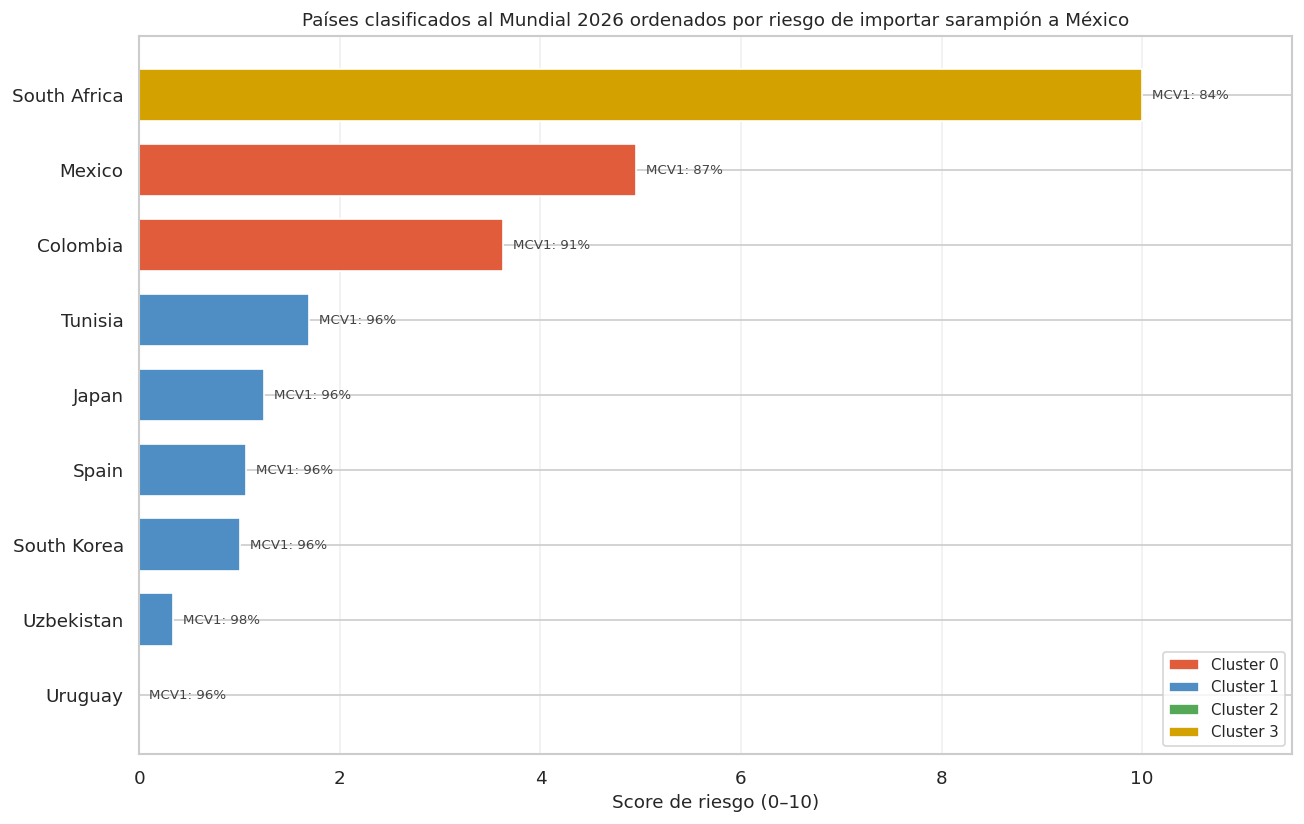

In [ ]:
# Visualización final: score de riesgo de los países del Mundial
top_wc = riesgo_mundial.head(20).copy()

# Color por cluster usando la paleta definida previamente en PCA
colors_bar = [palette[c] for c in top_wc['cluster']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top_wc['Country'],
    top_wc['score_riesgo_norm'],
    color=colors_bar,
    edgecolor='white',
    height=0.7
)

# Añadir cobertura MCV1 como anotación al final de cada barra
for bar, (_, row) in zip(bars, top_wc.iterrows()):
    ax.text(
        row['score_riesgo_norm'] + 0.1, bar.get_y() + bar.get_height() / 2,
        f"MCV1: {row['mcv1_mean']:.0f}%",
        va='center', fontsize=8, color='#444'
    )

ax.set_xlabel('Score de riesgo (0–10)', fontsize=11)
ax.set_title(
    'Países clasificados al Mundial 2026 ordenados por riesgo de importar sarampión a México',
    fontsize=11
)
ax.invert_yaxis() # Para que el país con mayor riesgo quede hasta arriba
ax.set_xlim(0, 11.5)
ax.grid(axis='x', alpha=0.3)

# Leyenda de clusters
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=palette[i], label=f'Cluster {i}')
    for i in sorted(cluster_df['cluster'].unique())
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Exportar resultados para el modelo supervisado

In [ ]:
# Guardar el dataset con los clusters asignados
# Nota: Si la columna 'ISO3' no existe, asegúrate de quitarla de esta lista.
columnas_salida = [
    'Country', 'cluster', 'score_riesgo_norm',
    'total_cases', 'mcv1_mean', 'mcv1_min', 'mcv1_tendencia',
    'clasificado_2026'
]

# Agregamos ISO3 solo si existe en el dataframe
if 'ISO3' in cluster_df.columns:
    columnas_salida.insert(1, 'ISO3')

output = cluster_df[columnas_salida].copy()

output.to_csv('content/data/processed/paises_cluster_riesgo.csv', index=False)
print('Archivo guardado en: content/data/processed/paises_cluster_riesgo.csv')

# Resumen estadístico por cluster
print('\nResumen final por cluster:')
print(
    cluster_df.groupby('cluster').agg(
        n_paises=('Country', 'count'),
        paises_mundial=('clasificado_2026', 'sum'),
        casos_promedio=('total_cases', 'mean'),
        mcv1_promedio=('mcv1_mean', 'mean'),
        score_promedio=('score_riesgo_norm', 'mean')
    ).round(2).to_string()
)


Archivo guardado en: content/data/processed/paises_cluster_riesgo.csv

Resumen final por cluster:
         n_paises  paises_mundial  casos_promedio  mcv1_promedio  score_promedio
cluster                                                                         
0               2               2           335.0          89.17            4.29
1               5               5          3104.0          96.68            1.06
2               1               1            11.0          95.50            0.00
3               1               1          2475.0          83.50           10.00


---
## 9. Conclusiones del Notebook 1

Escribe aquí tus conclusiones después de correr el notebook. Guía de preguntas:

1. **¿Cuántos clusters resultaron más interpretables?** ¿Coincidió el elbow con el silhouette?
2. **¿Qué países del Mundial 2026 cayeron en el cluster de mayor riesgo?** ¿Tienen sentido epidemiológicamente?
3. **¿Concordaron K-Means y clustering jerárquico?** ¿Qué países difirieron entre métodos?
4. **¿Qué variables resultaron más discriminantes** (ver loadings de PCA)?
5. **¿Qué implicación tiene para México?** Considerando que Jalisco ya tiene 4,232 casos confirmados en 2026.

### Siguiente paso
El archivo `paises_cluster_riesgo.csv` generado aquí se usará en el Notebook 2 (detección de anomalías en datos EFES) y en el ETL para construir la feature `riesgo_pais_origen` del modelo supervisado.

In [ ]:
print("=== CLUSTER DF ===")
print(cluster_df[['Country', 'cluster', 'ciudad_sede', 'total_cases',
                   'mcv1_mean', 'score_riesgo_norm']].to_string(index=False))
print(f"\nK final usado: {K_FINAL}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_df['cluster']):.3f}")
print(f"ARI (KMeans vs jerárquico): {adjusted_rand_score(cluster_df['cluster'], wc_df['cluster_jerarquico']):.3f}")

print("\n=== LOADINGS PCA ===")
print(loading_df)

=== CLUSTER DF ===
     Country  cluster ciudad_sede  total_cases  mcv1_mean  score_riesgo_norm
      Mexico        0        CDMX        223.0  87.166667               4.95
South Africa        3   Monterrey       2475.0  83.500000              10.00
 South Korea        1 Guadalajara        273.0  95.916667               1.00
     Tunisia        1   Monterrey       4756.0  96.333333               1.69
  Uzbekistan        1        CDMX       8480.0  98.333333               0.33
    Colombia        0        CDMX        447.0  91.166667               3.63
       Japan        1   Monterrey       1143.0  96.333333               1.24
       Spain        1 Guadalajara        868.0  96.500000               1.06
     Uruguay        2 Guadalajara         11.0  95.500000               0.00

K final usado: 4
Silhouette Score: 0.385
ARI (KMeans vs jerárquico): 1.000

=== LOADINGS PCA ===
                     PC1    PC2
total_cases        0.418 -0.517
months_with_cases  0.428 -0.513
mcv1_mean        